In [17]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_1182.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_121.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_156.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_148.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_1176.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_1245.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_1012.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_1197.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_1186.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_1393.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_1413.nc
/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/chimanimani_s2_120

**UTILITES LOADING**

In [18]:
import os
import glob
import random
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

******DATA LOADING PART******

In [19]:
import os
import glob
import xarray as xr

DATA_DIR = "/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/data/data"

nc_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.nc")))

print("=" * 70)
print("DATASET LOADING SUMMARY")
print("=" * 70)

print(f"Dataset path       : {DATA_DIR}")
print(f"Total .nc files    : {len(nc_files)}")

print("\nFirst 5 files:")
for f in nc_files[:5]:
    print("•", os.path.basename(f))

DATASET LOADING SUMMARY
Dataset path       : /kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/data/data
Total .nc files    : 3410

First 5 files:
• chimanimani_s2_1000.nc
• chimanimani_s2_1001.nc
• chimanimani_s2_1002.nc
• chimanimani_s2_1003.nc
• chimanimani_s2_1004.nc


*Available variables / bands*

In [20]:
sample_path = nc_files[0]
sample_ds = xr.open_dataset(sample_path)

print("=" * 70)
print("SAMPLE FILE INSPECTION")
print("=" * 70)

print(f"Sample file: {os.path.basename(sample_path)}")

print("\nAvailable variables:")
for var in sample_ds.variables:
    print("•", var)

print("\nDataset dimensions:")
print(sample_ds.dims)

sample_ds.close()

SAMPLE FILE INSPECTION
Sample file: chimanimani_s2_1000.nc

Available variables:
• B02
• B03
• B04
• B05
• B06
• B07
• B08
• B8A
• B11
• B12
• SCL
• MASK
• DEM
• spatial_ref
• x
• y
• time

Dataset dimensions:
FrozenMappingWarningOnValuesAccess({'time': 15, 'x': 128, 'y': 128})


*Sentinel-2 bands available*

In [21]:
sample_ds = xr.open_dataset(sample_path)

bands_available = [var for var in sample_ds.variables if var.startswith("B")]

print("=" * 70)
print("SENTINEL-2 BANDS AVAILABLE")
print("=" * 70)

print(f"Number of bands found: {len(bands_available)}")
print("Bands:", bands_available)

sample_ds.close()

SENTINEL-2 BANDS AVAILABLE
Number of bands found: 10
Bands: ['B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B11', 'B12']


*Important shape check*

In [22]:
sample_ds = xr.open_dataset(sample_path)

important_vars = ["SCL", "MASK", "DEM"] + bands_available

print("=" * 70)
print("IMPORTANT VARIABLE SHAPES")
print("=" * 70)

for var in important_vars:
    if var in sample_ds.variables:
        print(f"{var:8s} -> {sample_ds[var].shape}")
    else:
        print(f"{var:8s} -> Not found")

sample_ds.close()

IMPORTANT VARIABLE SHAPES
SCL      -> (15, 128, 128)
MASK     -> (15, 128, 128)
DEM      -> (15, 128, 128)
B02      -> (15, 128, 128)
B03      -> (15, 128, 128)
B04      -> (15, 128, 128)
B05      -> (15, 128, 128)
B06      -> (15, 128, 128)
B07      -> (15, 128, 128)
B08      -> (15, 128, 128)
B8A      -> (15, 128, 128)
B11      -> (15, 128, 128)
B12      -> (15, 128, 128)


# Dataset Structure Analysis

In this section, we inspect the dataset size and verify the dimensions of key variables used in the pipeline:
- DEM (Digital Elevation Model)
- MASK (Ground Truth Landslide Mask)
- SCL (Scene Classification Layer / Cloud Mask)

In [23]:
sample_ds = xr.open_dataset(nc_files[0])

print("=" * 70)
print("DATASET STRUCTURE SUMMARY")
print("=" * 70)

print(f"Total Number of Samples (.nc files): {len(nc_files)}")

print("\nVariable Shapes:")

for var in ["DEM", "MASK", "SCL"]:
    if var in sample_ds.variables:
        print(f"{var:6s} : {sample_ds[var].shape}")
    else:
        print(f"{var:6s} : Not Found")

sample_ds.close()

DATASET STRUCTURE SUMMARY
Total Number of Samples (.nc files): 3410

Variable Shapes:
DEM    : (15, 128, 128)
MASK   : (15, 128, 128)
SCL    : (15, 128, 128)


# Sample Data Visualization

Visualizing key inputs used in the landslide detection pipeline:
- DEM (Elevation Information)
- MASK (Ground Truth Landslide Regions)
- SCL (Cloud / Scene Classification Layer)

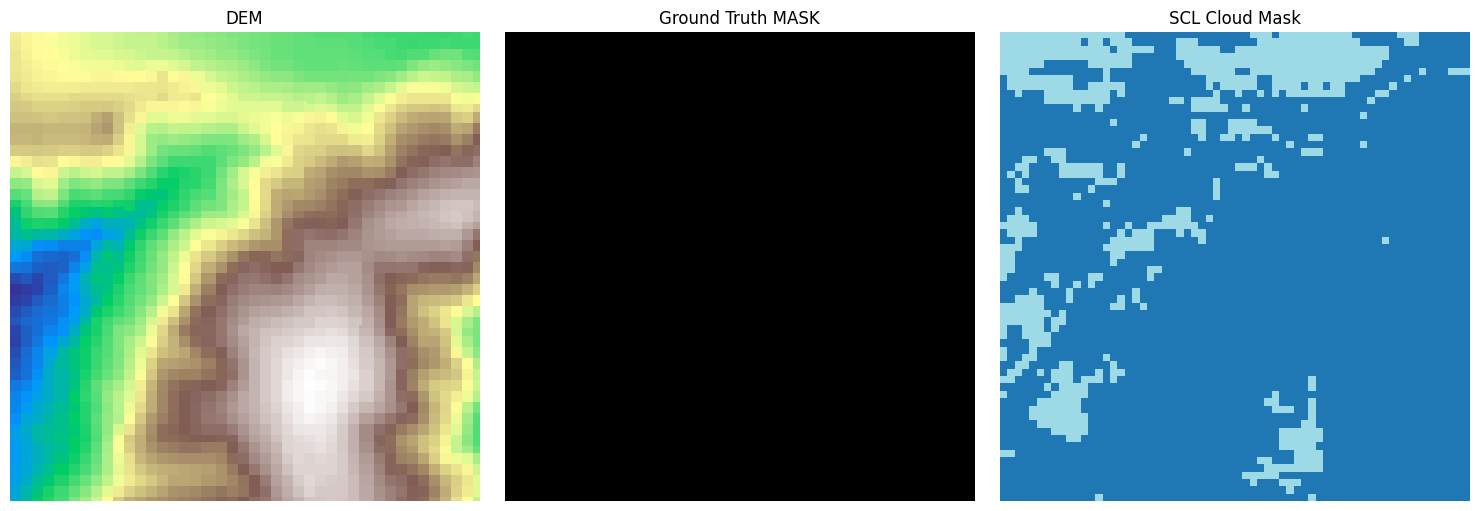

In [24]:
sample_ds = xr.open_dataset(nc_files[0])

fig, ax = plt.subplots(1, 3, figsize=(15,5))

ax[0].imshow(sample_ds["DEM"][0], cmap="terrain")
ax[0].set_title("DEM")

ax[1].imshow(sample_ds["MASK"][0], cmap="gray")
ax[1].set_title("Ground Truth MASK")

ax[2].imshow(sample_ds["SCL"][0], cmap="tab20")
ax[2].set_title("SCL Cloud Mask")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

sample_ds.close()

# Visualizing Satellite Inputs

This section visualizes the main input components used in the landslide detection pipeline: RGB image, DEM elevation map, ground-truth landslide mask, and SCL cloud/scene mask.

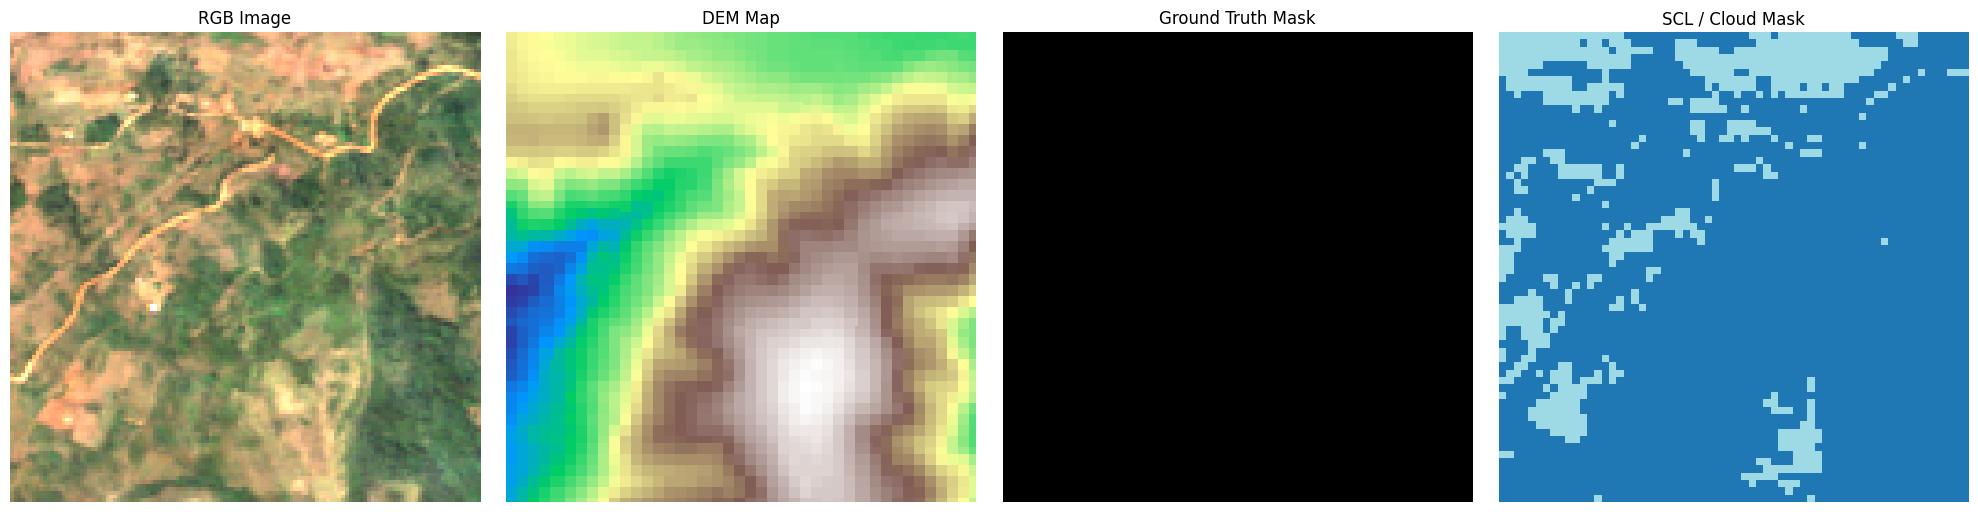

In [25]:
sample_ds = xr.open_dataset(nc_files[0])
t = 0

rgb = np.stack([
    sample_ds["B04"][t].values,
    sample_ds["B03"][t].values,
    sample_ds["B02"][t].values
], axis=-1)

rgb = np.clip(rgb / np.percentile(rgb, 98), 0, 1)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(rgb)
ax[0].set_title("RGB Image")

ax[1].imshow(sample_ds["DEM"][t], cmap="terrain")
ax[1].set_title("DEM Map")

ax[2].imshow(sample_ds["MASK"][t], cmap="gray")
ax[2].set_title("Ground Truth Mask")

ax[3].imshow(sample_ds["SCL"][t], cmap="tab20")
ax[3].set_title("SCL / Cloud Mask")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

sample_ds.close()

# Temporal Feature Analysis

Here we analyze how important spectral indices change over time. These indices help the model detect vegetation loss, surface disturbance, and bare-soil exposure caused by landslides.

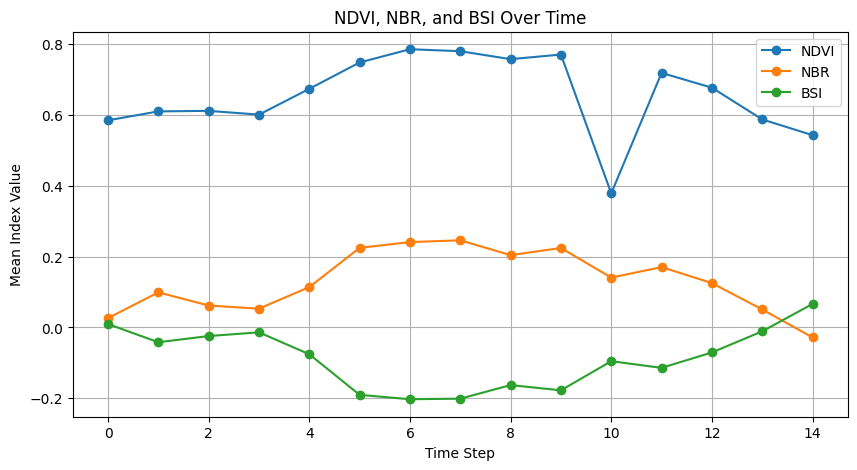

In [26]:
sample_ds = xr.open_dataset(nc_files[0])

ndvi_list = []
nbr_list = []
bsi_list = []

eps = 1e-6

for t in range(15):
    b02 = sample_ds["B02"][t].values.astype(np.float32)
    b04 = sample_ds["B04"][t].values.astype(np.float32)
    b08 = sample_ds["B08"][t].values.astype(np.float32)
    b11 = sample_ds["B11"][t].values.astype(np.float32)

    ndvi = (b08 - b04) / (b08 + b04 + eps)
    nbr = (b08 - b11) / (b08 + b11 + eps)
    bsi = ((b11 + b04) - (b08 + b02)) / ((b11 + b04) + (b08 + b02) + eps)

    ndvi_list.append(np.nanmean(ndvi))
    nbr_list.append(np.nanmean(nbr))
    bsi_list.append(np.nanmean(bsi))

sample_ds.close()

plt.figure(figsize=(10, 5))
plt.plot(range(15), ndvi_list, marker="o", label="NDVI")
plt.plot(range(15), nbr_list, marker="o", label="NBR")
plt.plot(range(15), bsi_list, marker="o", label="BSI")
plt.xlabel("Time Step")
plt.ylabel("Mean Index Value")
plt.title("NDVI, NBR, and BSI Over Time")
plt.legend()
plt.grid(True)
plt.show()

# Terrain and Cloud Analysis

This section visualizes terrain slope and cloud coverage. Slope is important because landslides commonly occur in steep regions, while cloud fraction helps identify unreliable satellite observations.

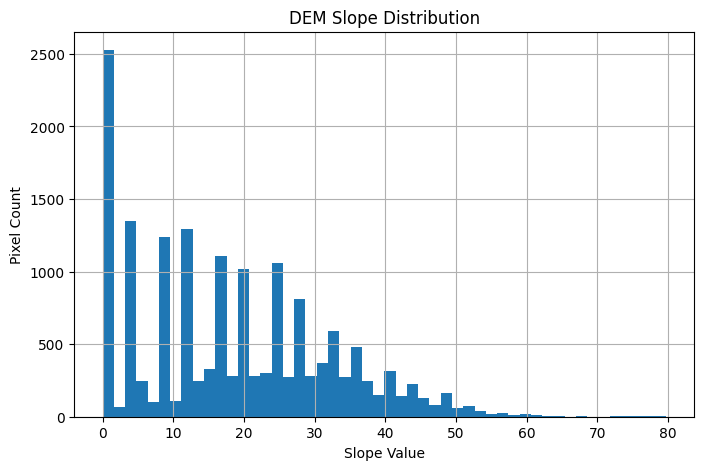

In [27]:
from scipy.ndimage import sobel

sample_ds = xr.open_dataset(nc_files[0])
dem = sample_ds["DEM"][0].values.astype(np.float32)

dx = sobel(dem, axis=1)
dy = sobel(dem, axis=0)
slope = np.sqrt(dx**2 + dy**2)

plt.figure(figsize=(8, 5))
plt.hist(slope.flatten(), bins=50)
plt.xlabel("Slope Value")
plt.ylabel("Pixel Count")
plt.title("DEM Slope Distribution")
plt.grid(True)
plt.show()

sample_ds.close()

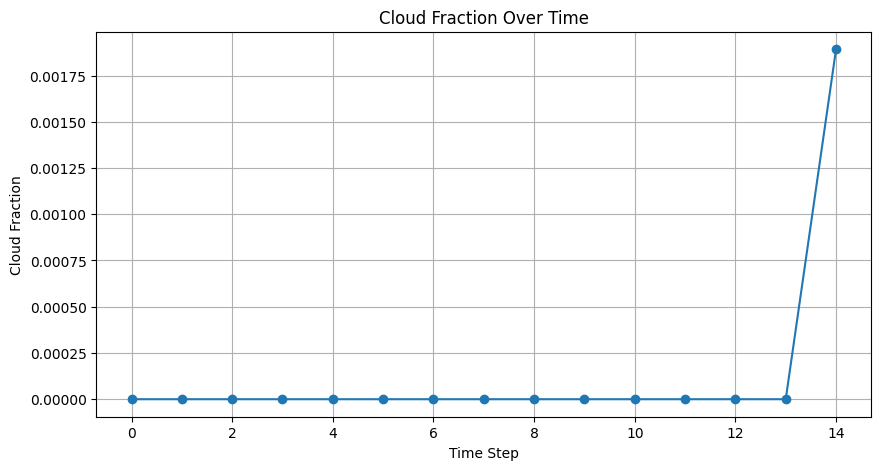

In [28]:
sample_ds = xr.open_dataset(nc_files[0])

cloud_fractions = []

for t in range(15):
    scl = sample_ds["SCL"][t].values
    cloud_mask = np.isin(scl, [3, 8, 9, 10])
    cloud_fractions.append(cloud_mask.mean())

sample_ds.close()

plt.figure(figsize=(10, 5))
plt.plot(range(15), cloud_fractions, marker="o")
plt.xlabel("Time Step")
plt.ylabel("Cloud Fraction")
plt.title("Cloud Fraction Over Time")
plt.grid(True)
plt.show()

# Dataset-Level Feature Relationship Analysis

In this section, we scan multiple `.nc` files and build a small analysis table containing:
- Landslide label from MASK
- Mean DEM slope
- NDVI change
- NBR change
- BSI change
- Cloud fraction

This helps us understand how terrain and spectral changes relate to landslide occurrence.

In [29]:
from scipy.ndimage import sobel
from tqdm import tqdm

MAX_FILES = 200
analysis_files = nc_files[:MAX_FILES]

records = []
eps = 1e-6

for path in tqdm(analysis_files, desc="Analyzing .nc files"):
    try:
        ds = xr.open_dataset(path)

        # Use first and last timestamp for simple change analysis
        t1 = 0
        t2 = ds["B04"].shape[0] - 1

        # Read bands
        b02_pre = ds["B02"][t1].values.astype(np.float32)
        b04_pre = ds["B04"][t1].values.astype(np.float32)
        b08_pre = ds["B08"][t1].values.astype(np.float32)
        b11_pre = ds["B11"][t1].values.astype(np.float32)

        b02_post = ds["B02"][t2].values.astype(np.float32)
        b04_post = ds["B04"][t2].values.astype(np.float32)
        b08_post = ds["B08"][t2].values.astype(np.float32)
        b11_post = ds["B11"][t2].values.astype(np.float32)

        # Compute indices
        ndvi_pre = (b08_pre - b04_pre) / (b08_pre + b04_pre + eps)
        ndvi_post = (b08_post - b04_post) / (b08_post + b04_post + eps)

        nbr_pre = (b08_pre - b11_pre) / (b08_pre + b11_pre + eps)
        nbr_post = (b08_post - b11_post) / (b08_post + b11_post + eps)

        bsi_pre = ((b11_pre + b04_pre) - (b08_pre + b02_pre)) / ((b11_pre + b04_pre) + (b08_pre + b02_pre) + eps)
        bsi_post = ((b11_post + b04_post) - (b08_post + b02_post)) / ((b11_post + b04_post) + (b08_post + b02_post) + eps)

        # DEM slope
        dem = ds["DEM"][0].values.astype(np.float32)
        dx = sobel(dem, axis=1)
        dy = sobel(dem, axis=0)
        slope = np.sqrt(dx**2 + dy**2)

        # Cloud fraction
        scl = ds["SCL"][t2].values
        cloud_mask = np.isin(scl, [3, 8, 9, 10])
        cloud_fraction = cloud_mask.mean()

        # Landslide label from mask
        mask = ds["MASK"].values
        landslide_label = int(mask.sum() > 0)

        records.append({
            "file": os.path.basename(path),
            "landslide_label": landslide_label,
            "mean_slope": np.nanmean(slope),
            "ndvi_change": np.nanmean(ndvi_post - ndvi_pre),
            "nbr_change": np.nanmean(nbr_post - nbr_pre),
            "bsi_change": np.nanmean(bsi_post - bsi_pre),
            "cloud_fraction": cloud_fraction
        })

        ds.close()

    except Exception as e:
        print("Skipped:", os.path.basename(path), "| Error:", e)

feature_df = pd.DataFrame(records)

print("Feature analysis dataframe created.")
print("Shape:", feature_df.shape)
feature_df.head()

Analyzing .nc files: 100%|██████████| 200/200 [00:40<00:00,  4.91it/s]

Feature analysis dataframe created.
Shape: (200, 7)


,file,landslide_label,mean_slope,ndvi_change,nbr_change,bsi_change,cloud_fraction
0,chimanimani_s2_1000.nc,0,18.176399,-0.041870,-0.054571,0.056760,0.001892
1,chimanimani_s2_1001.nc,1,24.388355,-0.037908,-0.058105,0.061897,0.000000
2,chimanimani_s2_1002.nc,1,37.701363,-0.051111,-0.064344,0.069385,0.000000
3,chimanimani_s2_1003.nc,1,35.360054,-0.022251,-0.027916,0.033045,0.000244
4,chimanimani_s2_1004.nc,1,37.919765,-0.134164,-0.183611,0.174230,0.000000


*Landslide vs Non-Landslide Count*

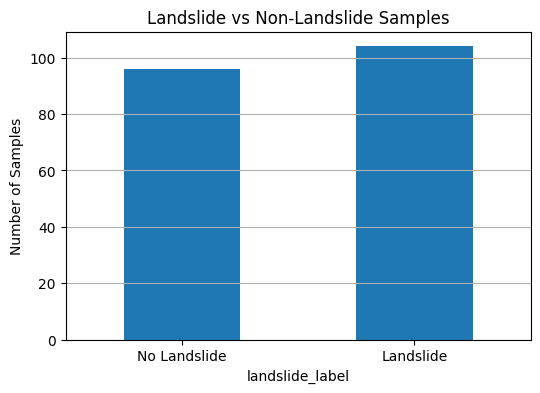

In [30]:
plt.figure(figsize=(6, 4))
feature_df["landslide_label"].value_counts().sort_index().plot(kind="bar")

plt.xticks([0, 1], ["No Landslide", "Landslide"], rotation=0)
plt.ylabel("Number of Samples")
plt.title("Landslide vs Non-Landslide Samples")
plt.grid(axis="y")
plt.show()

*Slope vs Landslide Label*

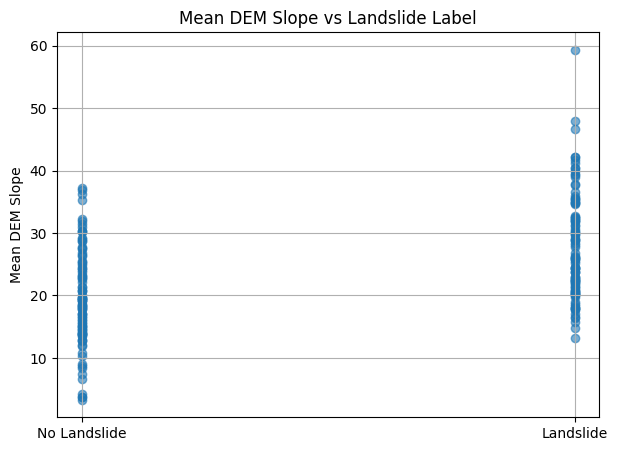

In [31]:
plt.figure(figsize=(7, 5))

plt.scatter(
    feature_df["landslide_label"],
    feature_df["mean_slope"],
    alpha=0.6
)

plt.xticks([0, 1], ["No Landslide", "Landslide"])
plt.ylabel("Mean DEM Slope")
plt.title("Mean DEM Slope vs Landslide Label")
plt.grid(True)
plt.show()

*NDVI / NBR / BSI Change vs Landslide Label*

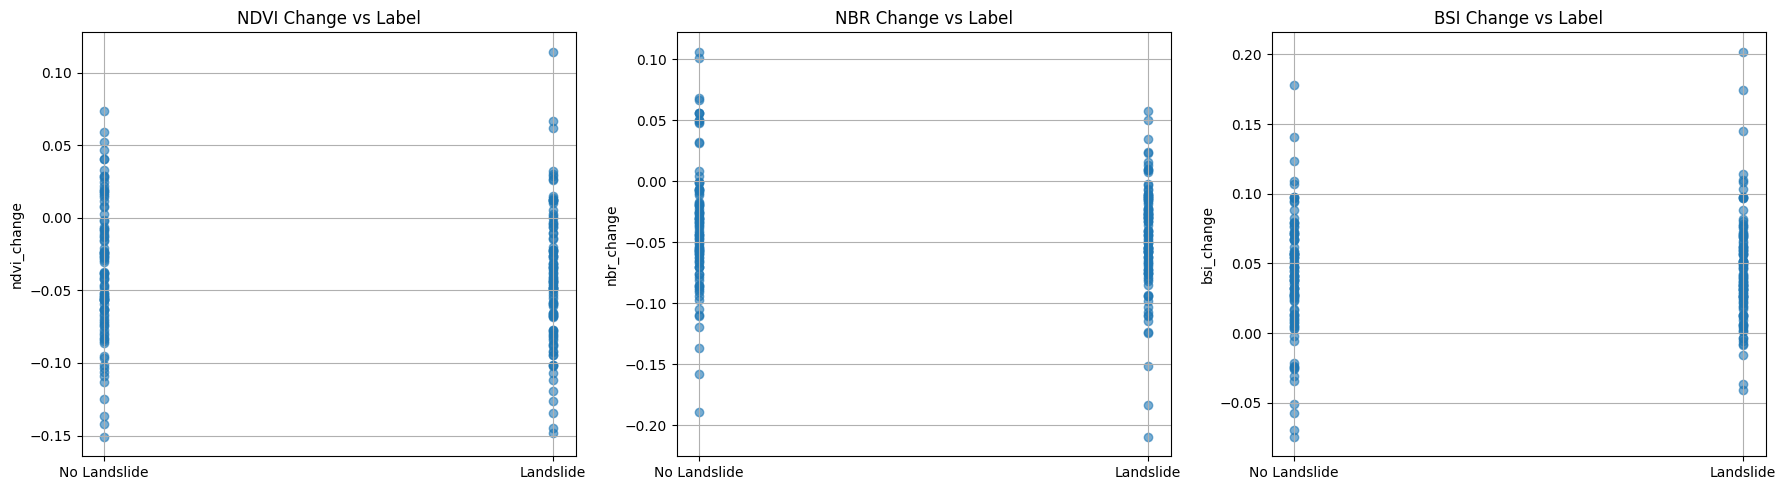

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

features = ["ndvi_change", "nbr_change", "bsi_change"]
titles = ["NDVI Change vs Label", "NBR Change vs Label", "BSI Change vs Label"]

for i, feature in enumerate(features):
    ax[i].scatter(
        feature_df["landslide_label"],
        feature_df[feature],
        alpha=0.6
    )
    ax[i].set_xticks([0, 1])
    ax[i].set_xticklabels(["No Landslide", "Landslide"])
    ax[i].set_ylabel(feature)
    ax[i].set_title(titles[i])
    ax[i].grid(True)

plt.tight_layout()
plt.show()

*Cloud Fraction vs Landslide Label*

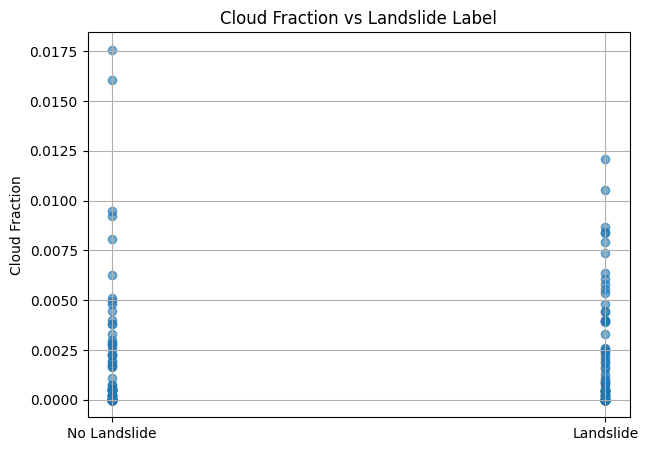

In [33]:
plt.figure(figsize=(7, 5))

plt.scatter(
    feature_df["landslide_label"],
    feature_df["cloud_fraction"],
    alpha=0.6
)

plt.xticks([0, 1], ["No Landslide", "Landslide"])
plt.ylabel("Cloud Fraction")
plt.title("Cloud Fraction vs Landslide Label")
plt.grid(True)
plt.show()

# Heatmap vs Ground Truth Mask Overlap

This section creates a simple landslide-likelihood heatmap using spectral index changes and compares it with the ground-truth MASK. This helps visualize whether the feature-based disturbance signal overlaps with actual landslide regions.

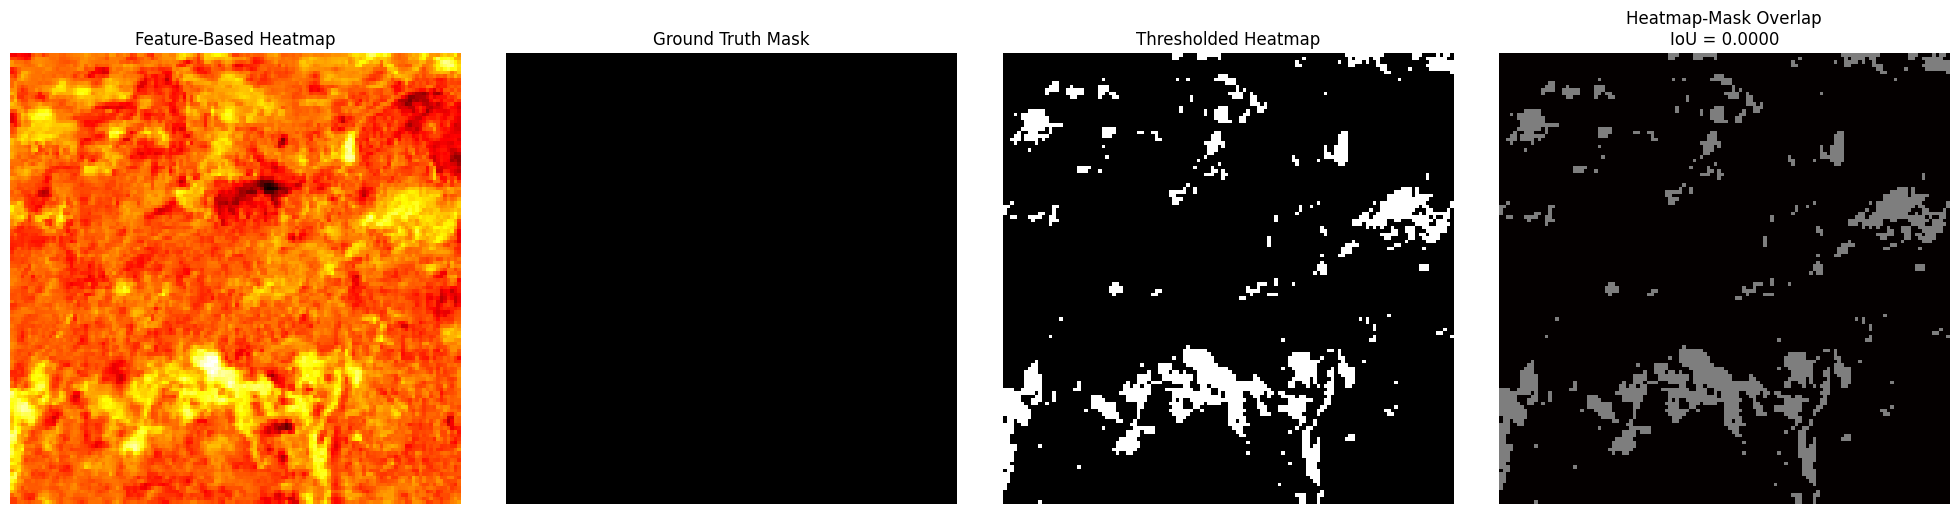

In [34]:
sample_ds = xr.open_dataset(nc_files[0])

eps = 1e-6

# Use first and last timestamp for before-after comparison
t1 = 0
t2 = sample_ds["B04"].shape[0] - 1

# Read pre-event bands
b02_pre = sample_ds["B02"][t1].values.astype(np.float32)
b04_pre = sample_ds["B04"][t1].values.astype(np.float32)
b08_pre = sample_ds["B08"][t1].values.astype(np.float32)
b11_pre = sample_ds["B11"][t1].values.astype(np.float32)

# Read post-event bands
b02_post = sample_ds["B02"][t2].values.astype(np.float32)
b04_post = sample_ds["B04"][t2].values.astype(np.float32)
b08_post = sample_ds["B08"][t2].values.astype(np.float32)
b11_post = sample_ds["B11"][t2].values.astype(np.float32)

# Compute spectral indices
ndvi_pre = (b08_pre - b04_pre) / (b08_pre + b04_pre + eps)
ndvi_post = (b08_post - b04_post) / (b08_post + b04_post + eps)

nbr_pre = (b08_pre - b11_pre) / (b08_pre + b11_pre + eps)
nbr_post = (b08_post - b11_post) / (b08_post + b11_post + eps)

bsi_pre = ((b11_pre + b04_pre) - (b08_pre + b02_pre)) / ((b11_pre + b04_pre) + (b08_pre + b02_pre) + eps)
bsi_post = ((b11_post + b04_post) - (b08_post + b02_post)) / ((b11_post + b04_post) + (b08_post + b02_post) + eps)

# Change features
ndvi_drop = ndvi_pre - ndvi_post
nbr_drop = nbr_pre - nbr_post
bsi_increase = bsi_post - bsi_pre

# Simple landslide-likelihood heatmap
heatmap = ndvi_drop + nbr_drop + bsi_increase

# Normalize heatmap to 0-1
heatmap = np.nan_to_num(heatmap)
heatmap_norm = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + eps)

# Ground truth mask
mask = sample_ds["MASK"][t2].values
mask_binary = mask > 0

# Threshold heatmap for overlap visualization
heatmap_binary = heatmap_norm > np.percentile(heatmap_norm, 90)

# Overlap score
intersection = np.logical_and(heatmap_binary, mask_binary).sum()
union = np.logical_or(heatmap_binary, mask_binary).sum()
iou = intersection / (union + eps)

fig, ax = plt.subplots(1, 4, figsize=(20, 5))

ax[0].imshow(heatmap_norm, cmap="hot")
ax[0].set_title("Feature-Based Heatmap")

ax[1].imshow(mask_binary, cmap="gray")
ax[1].set_title("Ground Truth Mask")

ax[2].imshow(heatmap_binary, cmap="gray")
ax[2].set_title("Thresholded Heatmap")

ax[3].imshow(mask_binary, cmap="gray")
ax[3].imshow(heatmap_binary, cmap="hot", alpha=0.5)
ax[3].set_title(f"Heatmap-Mask Overlap\nIoU = {iou:.4f}")

for a in ax:
    a.axis("off")

plt.tight_layout()
plt.show()

sample_ds.close()

# Stage 1 Setup and Hyperparameters

This section defines all important configuration values for Stage 1 training in one place.  
These parameters control dataset paths, model dimensions, training settings, loss weights, and checkpoint saving.

In [35]:
import os
import random
import numpy as np
import torch

# ============================================================
# STAGE 1 CONFIGURATION
# ============================================================

CFG = {
    # -------------------------
    # Dataset / Path Settings
    # -------------------------
    "data_dir": DATA_DIR,
    "checkpoint_dir": "./checkpoints",
    "stage1_checkpoint": "stage1_best.pth",

    # -------------------------
    # Reproducibility
    # -------------------------
    "seed": 42,

    # -------------------------
    # Stage 1 Input Settings
    # -------------------------
    "num_timestamps": 15,
    "num_pairs": 14,
    "num_features": 41,

    # -------------------------
    # Stage 1 Model Settings
    # -------------------------
    "s1_hidden_dim": 128,
    "s1_num_heads": 4,
    "s1_num_layers": 3,
    "s1_dropout": 0.3,

    # -------------------------
    # Stage 1 Training Settings
    # -------------------------
    "s1_epochs": 10,
    "s1_batch": 4,
    "s1_lr": 3e-4,
    "s1_weight_decay": 1e-4,
    "s1_grad_clip": 1.0,

    # -------------------------
    # Scheduler / Warmup
    # -------------------------
    "s1_warmup": 10,

    # -------------------------
    # Loss Weights
    # -------------------------
    "s1_pair_weight": 0.6,
    "s1_conf_weight": 0.1,
    "s1_curriculum_ep": 30,

    # -------------------------
    # Threshold Search
    # -------------------------
    "threshold_start": 0.20,
    "threshold_end": 0.80,
    "threshold_step": 0.02,
}

# ============================================================
# DEVICE SETUP
# ============================================================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ============================================================
# SEED SETUP
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG["seed"])

# ============================================================
# CHECKPOINT SETUP
# ============================================================

os.makedirs(CFG["checkpoint_dir"], exist_ok=True)
CKPT1 = os.path.join(CFG["checkpoint_dir"], CFG["stage1_checkpoint"])

# ============================================================
# CONFIG SUMMARY
# ============================================================

print("=" * 70)
print("STAGE 1 TRAINING SETUP")
print("=" * 70)
print(f"Device              : {DEVICE}")
print(f"Data Directory      : {CFG['data_dir']}")
print(f"Checkpoint Path     : {CKPT1}")
print(f"Epochs              : {CFG['s1_epochs']}")
print(f"Batch Size          : {CFG['s1_batch']}")
print(f"Learning Rate       : {CFG['s1_lr']}")
print(f"Weight Decay        : {CFG['s1_weight_decay']}")
print(f"Hidden Dimension    : {CFG['s1_hidden_dim']}")
print(f"Transformer Heads   : {CFG['s1_num_heads']}")
print(f"Transformer Layers  : {CFG['s1_num_layers']}")
print(f"Dropout             : {CFG['s1_dropout']}")
print(f"Pair Loss Weight    : {CFG['s1_pair_weight']}")
print(f"Confidence Weight   : {CFG['s1_conf_weight']}")
print("=" * 70)

STAGE 1 TRAINING SETUP
Device              : cuda
Data Directory      : /kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/data/data
Checkpoint Path     : ./checkpoints/stage1_best.pth
Epochs              : 10
Batch Size          : 4
Learning Rate       : 0.0003
Weight Decay        : 0.0001
Hidden Dimension    : 128
Transformer Heads   : 4
Transformer Layers  : 3
Dropout             : 0.3
Pair Loss Weight    : 0.6
Confidence Weight   : 0.1


# Stage 1 Data Utilities

This section defines helper functions for reading `.nc` files, extracting Sentinel-2 bands, DEM, masks, cloud information, and generating Stage 1 temporal features.

In [36]:
from scipy.ndimage import sobel
import torch
import torch.nn.functional as F

BANDS = ["B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B11", "B12"]
BAND_IDX = {b: i for i, b in enumerate(BANDS)}

def load_nc_file(path):
    ds = xr.open_dataset(path)

    bands = np.stack(
        [ds[b].values.astype(np.float32) for b in BANDS],
        axis=1
    ) / 10000.0

    bands = np.clip(bands, 0, 1)

    scl = ds["SCL"].values.astype(np.int16)
    mask = ds["MASK"].values.astype(np.uint8)

    dem_raw = ds["DEM"].values.astype(np.float32)
    dem = dem_raw[0] if dem_raw.ndim == 3 else dem_raw

    meta = dict(ds.attrs)
    ds.close()

    return {
        "bands": bands,
        "scl": scl,
        "mask": mask,
        "dem": dem,
        "meta": meta
    }


def get_cloud_mask(scl):
    return np.isin(scl, [3, 8, 9, 10])


def compute_dem_slope(dem):
    dx = sobel(dem, axis=1)
    dy = sobel(dem, axis=0)
    slope = np.sqrt(dx**2 + dy**2)
    return float(slope.mean()), float(slope.std())


def sliding_window_max(heatmap, window_size=7):
    h = torch.tensor(heatmap).unsqueeze(1)
    pad = window_size // 2
    pooled = F.max_pool2d(h, kernel_size=window_size, stride=1, padding=pad)
    return pooled.squeeze(1).mean(dim=(-1, -2)).numpy()


def permanence_check(bands, candidate_t, n_post=3):
    T = bands.shape[0]

    if candidate_t == 0 or candidate_t >= T - 1:
        return 0.0

    pre_b04 = bands[candidate_t - 1, BAND_IDX["B04"]]
    pre_b08 = bands[candidate_t - 1, BAND_IDX["B08"]]

    n_check = min(n_post, T - candidate_t - 1)

    if n_check == 0:
        return 1.0

    persistent = 0

    for k in range(1, n_check + 1):
        if (
            np.mean(bands[candidate_t + k, BAND_IDX["B04"]] - pre_b04) > 0
            and np.mean(bands[candidate_t + k, BAND_IDX["B08"]] - pre_b08) < 0
        ):
            persistent += 1

    return persistent / n_check


TIME_ENC = np.stack([
    np.sin(2 * np.pi * np.arange(14, dtype=np.float32) / 14),
    np.cos(2 * np.pi * np.arange(14, dtype=np.float32) / 14)
], axis=1)

In [37]:
from tqdm import tqdm

# Stage 1 Catalogue Building

This cell scans all `.nc` files and builds a catalogue containing file paths, landslide labels, and useful metadata required for Stage 1 training.

In [45]:
# ============================================================
# STAGE 1 CATALOGUE BUILDING
# ============================================================

catalog = []

for path in tqdm(nc_files, desc="Building catalogue"):
    try:
        ds = xr.open_dataset(path)

        mask = ds["MASK"].values
        landslide_label = int(mask.sum() > 0)

        catalog.append({
            "path": path,
            "file": os.path.basename(path),
            "label": landslide_label
        })

        ds.close()

    except Exception as e:
        print("Skipped:", os.path.basename(path), "| Error:", e)

catalog_df = pd.DataFrame(catalog)

print("=" * 70)
print("CATALOGUE SUMMARY")
print("=" * 70)
print("Total files in catalogue:", len(catalog_df))
print("\nLabel distribution:")
print(catalog_df["label"].value_counts())

catalog_df.head()
# ============================================================
# DEVICE CHECK
# ============================================================

import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("\n" + "=" * 70)
print("HARDWARE INFORMATION")
print("=" * 70)

if torch.cuda.is_available():
    print(f"Device Type : GPU")
    print(f"GPU Name    : {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("Device Type : CPU")

print("=" * 70)

Building catalogue: 100%|██████████| 3410/3410 [08:41<00:00,  6.54it/s]

CATALOGUE SUMMARY
Total files in catalogue: 3410

Label distribution:
label
0    1999
1    1411
Name: count, dtype: int64

HARDWARE INFORMATION
Device Type : GPU
GPU Name    : Tesla T4
CUDA Version: 12.8


# Train / Validation Split

This cell splits the catalogue into training and validation sets while preserving the landslide / non-landslide label distribution.

In [46]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    catalog_df,
    test_size=0.15,
    random_state=CFG["seed"],
    stratify=catalog_df["label"]
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

print("=" * 70)
print("TRAIN / VALIDATION SPLIT SUMMARY")
print("=" * 70)
print(f"Train samples : {len(train_df)}")
print(f"Val samples   : {len(val_df)}")

print("\nTrain label distribution:")
print(train_df["label"].value_counts())

print("\nValidation label distribution:")
print(val_df["label"].value_counts())
print("=" * 70)

TRAIN / VALIDATION SPLIT SUMMARY
Train samples : 2898
Val samples   : 512

Train label distribution:
label
0    1699
1    1199
Name: count, dtype: int64

Validation label distribution:
label
0    300
1    212
Name: count, dtype: int64


# Stage 1 Dataset

This cell creates the Stage 1 PyTorch Dataset. Each `.nc` file is converted into a feature matrix used by the Transformer model.

In [47]:
from torch.utils.data import Dataset

class Stage1Dataset(Dataset):
    def __init__(self, dataframe, augment=False):
        self.dataframe = dataframe.reset_index(drop=True)
        self.augment = augment
        self.samples = []

        print(f"Preloading {len(self.dataframe)} files...")

        for _, row in tqdm(self.dataframe.iterrows(), total=len(self.dataframe)):
            try:
                feats, _, _, _, _ = extract_stage1_features(row["path"])

                is_ls = int(row["label"])

                # pair label kept as 0 here because current catalogue has only binary label
                pair_label = 0

                self.samples.append((
                    torch.tensor(feats, dtype=torch.float32),
                    torch.tensor(pair_label, dtype=torch.long),
                    torch.tensor(is_ls, dtype=torch.float32)
                ))

            except Exception as e:
                print("Skipped:", row["file"], "| Error:", e)

        print(f"Loaded {len(self.samples)} samples.")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        feats, pair_label, is_ls = self.samples[idx]

        if self.augment:
            if random.random() > 0.5:
                feats = feats + torch.randn_like(feats) * 0.01

        return feats, pair_label, is_ls

# Stage 1 Feature Extraction Function

This function converts each `.nc` satellite file into the Stage 1 input format:  
`14 temporal pairs × 41 handcrafted features`.

It uses Sentinel-2 band changes, cloud masks, DEM slope, NDVI/NBR/BSI changes, heatmap score, permanence score, and time encoding.

In [48]:
CFG["window_size"] = 7
print("window_size added:", CFG["window_size"])

window_size added: 7


In [49]:
SIGN_VEC = np.array([
    0, 0, 0, 0, 0, 0,
    -1,  # B08 decrease
    -1,  # B8A decrease
    1,   # B11 increase
    1    # B12 increase
], dtype=np.float32)

print("SIGN_VEC defined:", SIGN_VEC)

SIGN_VEC defined: [ 0.  0.  0.  0.  0.  0. -1. -1.  1.  1.]


In [51]:
def extract_stage1_features(path):
    data = load_nc_file(path)

    bands = data["bands"]
    scl = data["scl"]
    dem = data["dem"]

    clouds = get_cloud_mask(scl)
    slope_mean, slope_std = compute_dem_slope(dem)

    ndvi_all = []
    nbr_all = []
    bsi_all = []

    eps = 1e-6

    for t in range(15):
        b = bands[t]

        ndvi = (
            b[BAND_IDX["B08"]] - b[BAND_IDX["B04"]]
        ) / (
            b[BAND_IDX["B08"]] + b[BAND_IDX["B04"]] + eps
        )

        nbr = (
            b[BAND_IDX["B08"]] - b[BAND_IDX["B11"]]
        ) / (
            b[BAND_IDX["B08"]] + b[BAND_IDX["B11"]] + eps
        )

        bsi = (
            (b[BAND_IDX["B11"]] + b[BAND_IDX["B04"]])
            - (b[BAND_IDX["B08"]] + b[BAND_IDX["B02"]])
        ) / (
            (b[BAND_IDX["B11"]] + b[BAND_IDX["B04"]])
            + (b[BAND_IDX["B08"]] + b[BAND_IDX["B02"]])
            + eps
        )

        ndvi_all.append(ndvi.mean())
        nbr_all.append(nbr.mean())
        bsi_all.append(bsi.mean())

    # Change vector between consecutive timestamps
    cv = bands[1:] - bands[:-1]

    # Landslide-sign heatmap
    sign_vec = SIGN_VEC[np.newaxis, :, np.newaxis, np.newaxis]
    heatmap = np.mean(np.maximum(cv * sign_vec, 0), axis=1)

    # Sliding window score
    sw_scores = sliding_window_max(
        heatmap,
        CFG["window_size"]
    )

    # Cloud pair mask
    cloud_pair = clouds[:-1] | clouds[1:]

    features = []

    for t in range(14):
        valid = ~cloud_pair[t]
        n_valid = valid.sum()
        cloud_frac = 1.0 - float(valid.mean())

        if n_valid < 10:
            mean_cv = np.zeros(10, dtype=np.float32)
            sig = 0.0
            pre_abs = np.zeros(10, dtype=np.float32)
            post_abs = np.zeros(10, dtype=np.float32)

        else:
            mean_cv = cv[t][:, valid].mean(axis=1).astype(np.float32)

            sig = float(
                np.mean(
                    np.maximum(mean_cv * SIGN_VEC, 0)
                )
            )

            pre_abs = bands[t][:, valid].mean(axis=1).astype(np.float32)
            post_abs = bands[t + 1][:, valid].mean(axis=1).astype(np.float32)

        perm = float(
            permanence_check(
                bands,
                t + 1
            )
        )

        row = np.concatenate([
            mean_cv,
            [sig],
            [sw_scores[t]],
            [perm],
            [cloud_frac],
            [
                ndvi_all[t + 1] - ndvi_all[t],
                nbr_all[t + 1] - nbr_all[t],
                bsi_all[t + 1] - bsi_all[t]
            ],
            pre_abs,
            post_abs,
            [slope_mean, slope_std],
            TIME_ENC[t]
        ]).astype(np.float32)

        features.append(row)

    return (
        np.stack(features, axis=0),
        heatmap,
        bands,
        data["mask"],
        data["dem"]
    )


print("extract_stage1_features() defined successfully.")

extract_stage1_features() defined successfully.


# Stage 1 DataLoaders

This cell creates balanced training and validation DataLoaders. WeightedRandomSampler is used to reduce the effect of class imbalance.

In [52]:
from torch.utils.data import DataLoader, WeightedRandomSampler

print("Building Stage 1 datasets...")

train_ds1 = Stage1Dataset(train_df, augment=False)
val_ds1 = Stage1Dataset(val_df, augment=False)

is_ls_flags = [sample[2].item() for sample in train_ds1.samples]

n_pos = max(1, sum(is_ls_flags))
n_neg = max(1, len(is_ls_flags) - n_pos)

sample_weights = [
    1.0 / n_pos if flag == 1 else 1.0 / n_neg
    for flag in is_ls_flags
]

sampler = WeightedRandomSampler(
    sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

train_dl1 = DataLoader(
    train_ds1,
    batch_size=CFG["s1_batch"],
    sampler=sampler,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_dl1 = DataLoader(
    val_ds1,
    batch_size=CFG["s1_batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("=" * 70)
print("STAGE 1 DATALOADER SUMMARY")
print("=" * 70)
print(f"Train dataset size : {len(train_ds1)}")
print(f"Val dataset size   : {len(val_ds1)}")
print(f"Train batches      : {len(train_dl1)}")
print(f"Val batches        : {len(val_dl1)}")
print(f"Positive samples   : {int(n_pos)}")
print(f"Negative samples   : {int(n_neg)}")
print(f"Batch size         : {CFG['s1_batch']}")
print("=" * 70)

Building Stage 1 datasets...
Preloading 2898 files...


100%|██████████| 2898/2898 [15:01<00:00,  3.22it/s]


Loaded 2898 samples.
Preloading 512 files...


100%|██████████| 512/512 [02:35<00:00,  3.29it/s]

Loaded 512 samples.
STAGE 1 DATALOADER SUMMARY
Train dataset size : 2898
Val dataset size   : 512
Train batches      : 725
Val batches        : 128
Positive samples   : 1199
Negative samples   : 1699
Batch size         : 4


# Stage 1 Transformer Model

This cell defines the Transformer-based Stage 1 model.  
The model takes a `14 × 41` feature matrix and predicts:
- Landslide / No Landslide
- Event pair index
- Confidence score

In [53]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

In [54]:
CFG["s1_focal_alpha"] = 0.75
CFG["s1_focal_gamma"] = 2.0
CFG["s1_label_smooth"] = 0.1

In [55]:
print(CFG)

{'data_dir': '/kaggle/input/datasets/ayushkumar5944/sen12landslides-dataak/data/data', 'checkpoint_dir': './checkpoints', 'stage1_checkpoint': 'stage1_best.pth', 'seed': 42, 'num_timestamps': 15, 'num_pairs': 14, 'num_features': 41, 's1_hidden_dim': 128, 's1_num_heads': 4, 's1_num_layers': 3, 's1_dropout': 0.3, 's1_epochs': 10, 's1_batch': 4, 's1_lr': 0.0003, 's1_weight_decay': 0.0001, 's1_grad_clip': 1.0, 's1_warmup': 10, 's1_pair_weight': 0.6, 's1_conf_weight': 0.1, 's1_curriculum_ep': 30, 'threshold_start': 0.2, 'threshold_end': 0.8, 'threshold_step': 0.02, 'window_size': 7, 's1_focal_alpha': 0.75, 's1_focal_gamma': 2.0, 's1_label_smooth': 0.1}


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [57]:
# ============================================================
# MISSING STAGE 1 LOSS CONFIGS
# ============================================================

CFG["s1_focal_alpha"] = 0.75
CFG["s1_focal_gamma"] = 2.0
CFG["s1_label_smooth"] = 0.1

print("Stage 1 loss config added:")
print("s1_focal_alpha  :", CFG["s1_focal_alpha"])
print("s1_focal_gamma  :", CFG["s1_focal_gamma"])
print("s1_label_smooth :", CFG["s1_label_smooth"])

Stage 1 loss config added:
s1_focal_alpha  : 0.75
s1_focal_gamma  : 2.0
s1_label_smooth : 0.1


In [58]:
class Stage1Model(nn.Module):
    def __init__(
        self,
        feat_dim=41,
        hidden=256,
        n_heads=8,
        n_layers=4,
        ffn_dim=512,
        dropout=0.3,
        n_pairs=14
    ):
        super().__init__()

        self.pair_encoder = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout / 2)
        )

        self.pos_embed = nn.Parameter(
            torch.randn(1, n_pairs, hidden) * 0.02
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout / 2,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            enc_layer,
            num_layers=n_layers,
            enable_nested_tensor=False
        )

        self.ls_attn = nn.Linear(hidden, 1)

        self.ls_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1)
        )

        self.pair_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

        self.conf_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        enc = self.pair_encoder(x) + self.pos_embed
        ctx = self.transformer(enc)

        pair_logits = self.pair_head(ctx).squeeze(-1)

        attn_w = torch.softmax(self.ls_attn(ctx), dim=1)
        pooled = (attn_w * ctx).sum(dim=1)

        ls_logit = self.ls_head(pooled).squeeze(-1)
        conf_logit = self.conf_head(pooled).squeeze(-1)

        return ls_logit, pair_logits, conf_logit


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce = F.binary_cross_entropy_with_logits(
            logits,
            targets,
            reduction="none"
        )

        prob = torch.sigmoid(logits)
        pt = torch.where(targets == 1, prob, 1 - prob)

        at = torch.where(
            targets == 1,
            torch.full_like(pt, self.alpha),
            torch.full_like(pt, 1 - self.alpha)
        )

        loss = at * (1 - pt) ** self.gamma * bce
        return loss.mean()


class LabelSmoothCE(nn.Module):
    def __init__(self, n=14, s=0.1):
        super().__init__()
        self.n = n
        self.s = s

    def forward(self, logits, targets):
        log_probs = F.log_softmax(logits, dim=-1)
        smooth_value = self.s / (self.n - 1)

        with torch.no_grad():
            smooth_targets = torch.full_like(log_probs, smooth_value)
            smooth_targets.scatter_(
                1,
                targets.unsqueeze(1),
                1.0 - self.s
            )

        return -(smooth_targets * log_probs).sum(dim=-1).mean()


class ConfLoss(nn.Module):
    def forward(self, conf_logits, pair_logits, labels):
        confidence_target = (
            pair_logits.argmax(dim=1) == labels
        ).float()

        return F.binary_cross_entropy_with_logits(
            conf_logits,
            confidence_target
        )


focal_ls = FocalLoss(
    alpha=CFG["s1_focal_alpha"],
    gamma=CFG["s1_focal_gamma"]
).to(DEVICE)

ce_pair = LabelSmoothCE(
    n=14,
    s=CFG["s1_label_smooth"]
).to(DEVICE)

conf_loss = ConfLoss().to(DEVICE)

print("=" * 70)
print("STAGE 1 MODEL DEFINED")
print("=" * 70)

n_params = sum(
    p.numel()
    for p in Stage1Model().parameters()
    if p.requires_grad
)

print(f"Stage1Model trainable parameters: {n_params:,}")
print("=" * 70)

STAGE 1 MODEL DEFINED
Stage1Model trainable parameters: 2,247,620


# Stage 1 Training

This cell trains the Stage 1 Transformer model using:
- Focal Loss for landslide classification
- Label-Smoothed Cross Entropy for event-pair prediction
- Confidence loss for prediction confidence
- AdamW optimizer
- Cosine learning-rate scheduler

In [59]:
s1_model = Stage1Model().to(DEVICE)

optimizer1 = optim.AdamW(
    s1_model.parameters(),
    lr=CFG["s1_lr"],
    weight_decay=1e-4
)


def lr_lambda1(epoch):
    if epoch < CFG["s1_warmup"]:
        return (epoch + 1) / CFG["s1_warmup"]

    progress = (
        epoch - CFG["s1_warmup"]
    ) / max(1, CFG["s1_epochs"] - CFG["s1_warmup"])

    return 0.01 + 0.5 * 0.99 * (1 + np.cos(np.pi * progress))


scheduler1 = optim.lr_scheduler.LambdaLR(
    optimizer1,
    lr_lambda1
)

CKPT1 = os.path.join(
    CFG["checkpoint_dir"],
    "stage1_best.pth"
)

history1 = {
    "train_loss": [],
    "val_loss": [],
    "acc": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "pair_acc": [],
    "pair_off1": []
}

best_f1_s1 = 0.0
best_thresh_s1 = 0.5

print("=" * 100)
print("STAGE 1 TRAINING STARTED")
print("=" * 100)
print(f"Parameters: {sum(p.numel() for p in s1_model.parameters() if p.requires_grad):,}")
print(f"Device    : {DEVICE}")
print(f"Epochs    : {CFG['s1_epochs']}")
print(f"Batch     : {CFG['s1_batch']}")
print("=" * 100)

print(
    f'{"Ep":>4} {"TrLoss":>8} {"VlLoss":>8} {"Acc":>6} '
    f'{"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6} '
    f'{"PrAcc":>7} {"Pr±1":>6} {"LR":>8}'
)

print("-" * 100)

for epoch in range(1, CFG["s1_epochs"] + 1):

    # -------------------------
    # Training
    # -------------------------
    s1_model.train()

    total_loss = 0.0
    n_batches = 0

    pair_w = max(
        0.0,
        min(
            CFG["s1_pair_weight"],
            CFG["s1_pair_weight"]
            * (epoch - CFG["s1_curriculum_ep"])
            / max(1, CFG["s1_epochs"] - CFG["s1_curriculum_ep"])
        )
    )

    for feats, pair_labels, is_ls in train_dl1:
        feats = feats.to(DEVICE)
        pair_labels = pair_labels.to(DEVICE)
        is_ls = is_ls.to(DEVICE)

        ls_logit, pair_logits, conf_logit = s1_model(feats)

        loss_ls = focal_ls(ls_logit, is_ls)

        annotated = is_ls.bool()

        if annotated.sum() > 0 and pair_w > 0:
            loss_pair = ce_pair(
                pair_logits[annotated],
                pair_labels[annotated]
            )

            loss_conf = conf_loss(
                conf_logit[annotated],
                pair_logits[annotated],
                pair_labels[annotated]
            )
        else:
            loss_pair = torch.tensor(0.0, device=DEVICE)
            loss_conf = torch.tensor(0.0, device=DEVICE)

        loss = loss_ls + pair_w * loss_pair + 0.1 * loss_conf

        optimizer1.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            s1_model.parameters(),
            1.0
        )

        optimizer1.step()

        total_loss += loss.item()
        n_batches += 1

    # -------------------------
    # Validation
    # -------------------------
    s1_model.eval()

    val_loss = 0.0
    n_val_batches = 0

    ls_probs = []
    ls_true_all = []
    pair_preds = []
    pair_true_all = []

    with torch.no_grad():
        for feats, pair_labels, is_ls in val_dl1:
            feats = feats.to(DEVICE)
            pair_labels = pair_labels.to(DEVICE)
            is_ls = is_ls.to(DEVICE)

            ls_logit, pair_logits, _ = s1_model(feats)

            loss_ls = focal_ls(ls_logit, is_ls)

            annotated = is_ls.bool()

            if annotated.sum() > 0:
                loss_pair = ce_pair(
                    pair_logits[annotated],
                    pair_labels[annotated]
                )
            else:
                loss_pair = torch.tensor(0.0, device=DEVICE)

            val_loss += (loss_ls + 0.5 * loss_pair).item()
            n_val_batches += 1

            ls_probs.extend(
                torch.sigmoid(ls_logit).cpu().numpy()
            )

            ls_true_all.extend(
                is_ls.cpu().numpy()
            )

            if annotated.sum() > 0:
                pair_preds.extend(
                    pair_logits[annotated].argmax(dim=1).cpu().numpy()
                )
                pair_true_all.extend(
                    pair_labels[annotated].cpu().numpy()
                )

    ls_probs = np.array(ls_probs)
    ls_true_all = np.array(ls_true_all)

    # -------------------------
    # Threshold Search
    # -------------------------
    best_f1_v = 0.0
    best_thr = 0.5

    for thr in np.arange(0.2, 0.8, 0.02):
        preds = (ls_probs > thr).astype(int)
        f1 = f1_score(
            ls_true_all,
            preds,
            zero_division=0
        )

        if f1 > best_f1_v:
            best_f1_v = f1
            best_thr = thr

    ls_preds = (ls_probs > best_thr).astype(int)

    pair_acc = (
        accuracy_score(pair_true_all, pair_preds)
        if len(pair_preds) > 0 else 0.0
    )

    pair_off1 = (
        sum(
            abs(int(a) - int(b)) <= 1
            for a, b in zip(pair_true_all, pair_preds)
        ) / max(1, len(pair_true_all))
    )

    val_metrics = {
        "loss": val_loss / max(1, n_val_batches),
        "acc": accuracy_score(ls_true_all, ls_preds),
        "precision": precision_score(ls_true_all, ls_preds, zero_division=0),
        "recall": recall_score(ls_true_all, ls_preds, zero_division=0),
        "f1": best_f1_v,
        "auc": roc_auc_score(ls_true_all, ls_probs)
        if len(set(ls_true_all)) > 1 else 0.0,
        "pair_acc": pair_acc,
        "pair_off1": pair_off1
    }

    history1["train_loss"].append(
        total_loss / max(1, n_batches)
    )
    history1["val_loss"].append(
        val_metrics["loss"]
    )

    for key in [
        "acc",
        "precision",
        "recall",
        "f1",
        "auc",
        "pair_acc",
        "pair_off1"
    ]:
        history1[key].append(val_metrics[key])

    scheduler1.step()

    flag = ""

    if val_metrics["f1"] >= best_f1_s1:
        best_f1_s1 = val_metrics["f1"]
        best_thresh_s1 = best_thr

        torch.save(
            {
                "epoch": epoch,
                "model_state": s1_model.state_dict(),
                "val_metrics": val_metrics,
                "best_thresh": best_thr,
                "history": history1
            },
            CKPT1
        )

        flag = "<- saved"

    lr = optimizer1.param_groups[0]["lr"]

    print(
        f'{epoch:>4} '
        f'{total_loss / max(1, n_batches):>8.4f} '
        f'{val_metrics["loss"]:>8.4f} '
        f'{val_metrics["acc"]:>6.3f} '
        f'{val_metrics["precision"]:>6.3f} '
        f'{val_metrics["recall"]:>6.3f} '
        f'{val_metrics["f1"]:>6.3f} '
        f'{val_metrics["auc"]:>6.3f} '
        f'{pair_acc:>7.3f} '
        f'{pair_off1:>6.3f} '
        f'{lr:>8.2e}  {flag}'
    )

ckpt1 = torch.load(
    CKPT1,
    map_location=DEVICE,
    weights_only=False
)

s1_model.load_state_dict(
    ckpt1["model_state"]
)

best_thresh_s1 = ckpt1["best_thresh"]

print("\n" + "=" * 100)
print("STAGE 1 TRAINING COMPLETE")
print("=" * 100)
print(f"Best F1 Score     : {best_f1_s1:.4f}")
print(f"Best Threshold    : {best_thresh_s1:.2f}")
print(f"Checkpoint Saved  : {CKPT1}")
print("=" * 100)

STAGE 1 TRAINING STARTED
Parameters: 2,247,620
Device    : cuda
Epochs    : 10
Batch     : 4
  Ep   TrLoss   VlLoss    Acc   Prec    Rec     F1    AUC   PrAcc   Pr±1       LR
----------------------------------------------------------------------------------------------------
   1   0.0575   1.2380  0.715  0.607  0.882  0.719  0.806   0.005  0.005 6.00e-05  <- saved
   2   0.0543   1.2345  0.758  0.654  0.882  0.751  0.860   0.009  0.019 9.00e-05  <- saved
   3   0.0548   1.2284  0.764  0.655  0.906  0.760  0.853   0.009  0.024 1.20e-04  <- saved
   4   0.0552   1.2101  0.793  0.684  0.929  0.788  0.878   0.005  0.019 1.50e-04  <- saved
   5   0.0549   1.2483  0.795  0.688  0.925  0.789  0.925   0.005  0.009 1.80e-04  <- saved
   6   0.0555   1.2018  0.805  0.692  0.953  0.802  0.926   0.005  0.014 2.10e-04  <- saved
   7   0.0490   1.1941  0.818  0.720  0.920  0.807  0.928   0.019  0.028 2.40e-04  <- saved
   8   0.0470   1.2003  0.830  0.743  0.901  0.814  0.931   0.014  0.019 2.70e-0

**STAGE 1 OUTPUT VISUALIZATIONS**

Training vs Validation Loss

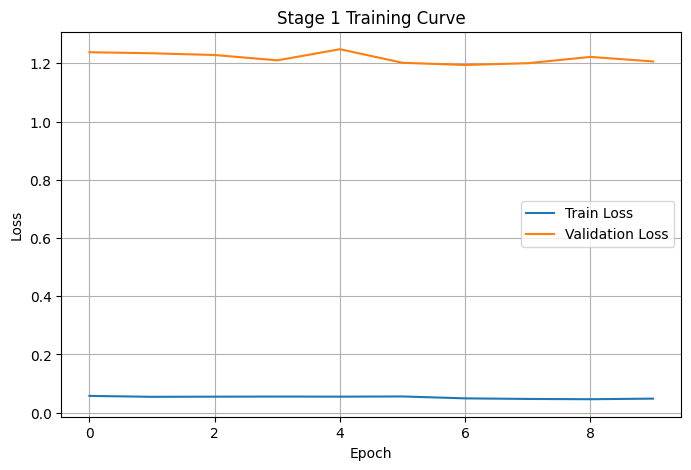

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history1["train_loss"], label="Train Loss")
plt.plot(history1["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Stage 1 Training Curve")
plt.legend()
plt.grid(True)
plt.show()

Accuracy / F1 Curve

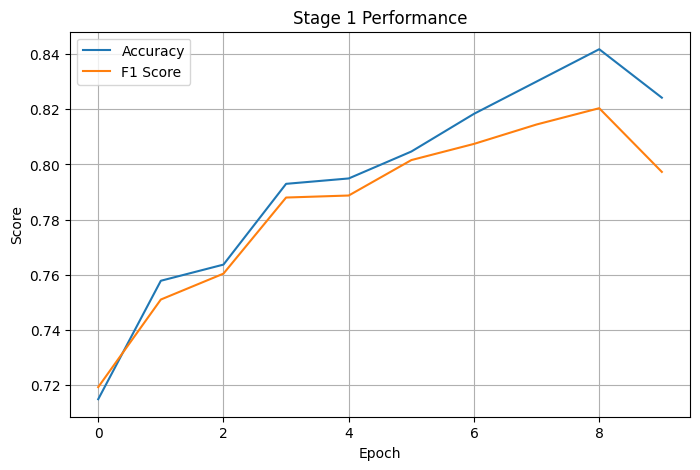

In [61]:
plt.figure(figsize=(8,5))

plt.plot(history1["acc"], label="Accuracy")
plt.plot(history1["f1"], label="F1 Score")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Stage 1 Performance")
plt.legend()
plt.grid(True)
plt.show()

Precision vs Recall

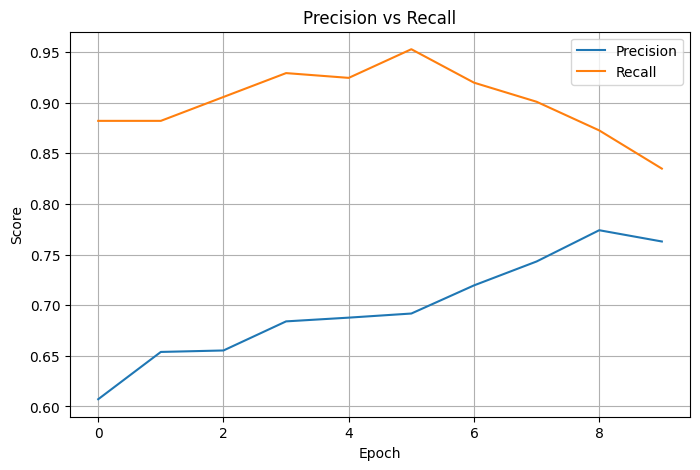

In [62]:
plt.figure(figsize=(8,5))

plt.plot(history1["precision"], label="Precision")
plt.plot(history1["recall"], label="Recall")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Precision vs Recall")
plt.legend()
plt.grid(True)
plt.show()

AUC Curve

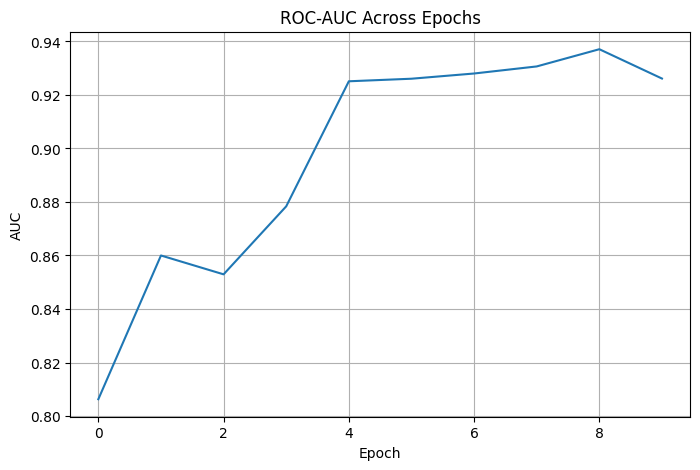

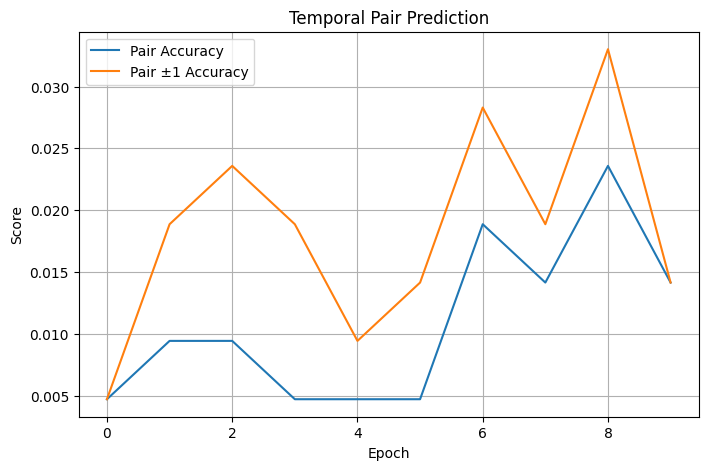

In [63]:
plt.figure(figsize=(8,5))

plt.plot(history1["auc"])

plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("ROC-AUC Across Epochs")
plt.grid(True)
plt.show()
plt.figure(figsize=(8,5))

plt.plot(history1["pair_acc"], label="Pair Accuracy")
plt.plot(history1["pair_off1"], label="Pair ±1 Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Score")
plt.title("Temporal Pair Prediction")
plt.legend()
plt.grid(True)
plt.show()

**STAGE 1MODIFIED TRAINING AGAIN**

In [64]:
# ============================================================
# EXPERIMENT 2 CONFIG
# ============================================================

CFG["s1_epochs"] = 50      # previously 30
CFG["s1_batch"] = 8        # previously 4
CFG["s1_lr"] = 1e-4        # slightly lower
CFG["s1_warmup"] = 5

CFG["experiment_name"] = "stage1_exp2"

print("="*70)
print("STAGE 1 EXPERIMENT 2")
print("="*70)

print("Epochs      :", CFG["s1_epochs"])
print("Batch Size  :", CFG["s1_batch"])
print("LearningRate:", CFG["s1_lr"])
print("Warmup      :", CFG["s1_warmup"])

print("="*70)

STAGE 1 EXPERIMENT 2
Epochs      : 50
Batch Size  : 8
LearningRate: 0.0001
Warmup      : 5


In [66]:
# ============================================================
# EXPERIMENT 2 SETTINGS
# ============================================================

CFG_EXP2 = CFG.copy()

CFG_EXP2["s1_epochs"] = 50
CFG_EXP2["s1_batch"] = 8
CFG_EXP2["s1_lr"] = 1e-4

print(CFG_EXP2["s1_epochs"])
print(CFG_EXP2["s1_batch"])
print(CFG_EXP2["s1_lr"])
s1_model = Stage1Model().to(DEVICE)

optimizer1 = optim.AdamW(
    s1_model.parameters(),
    lr=CFG["s1_lr"],
    weight_decay=1e-4
)


def lr_lambda1(epoch):
    if epoch < CFG["s1_warmup"]:
        return (epoch + 1) / CFG["s1_warmup"]

    progress = (
        epoch - CFG["s1_warmup"]
    ) / max(1, CFG["s1_epochs"] - CFG["s1_warmup"])

    return 0.01 + 0.5 * 0.99 * (1 + np.cos(np.pi * progress))


scheduler1 = optim.lr_scheduler.LambdaLR(
    optimizer1,
    lr_lambda1
)

CKPT1 = os.path.join(
    CFG["checkpoint_dir"],
    "stage1_best.pth"
)

history1 = {
    "train_loss": [],
    "val_loss": [],
    "acc": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "pair_acc": [],
    "pair_off1": []
}

best_f1_s1 = 0.0
best_thresh_s1 = 0.5

print("=" * 100)
print("STAGE 1 TRAINING STARTED EXPERIMENT 2")
print("=" * 100)
print(f"Parameters: {sum(p.numel() for p in s1_model.parameters() if p.requires_grad):,}")
print(f"Device    : {DEVICE}")
print(f"Epochs    : {CFG['s1_epochs']}")
print(f"Batch     : {CFG['s1_batch']}")
print("=" * 100)

print(
    f'{"Ep":>4} {"TrLoss":>8} {"VlLoss":>8} {"Acc":>6} '
    f'{"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6} '
    f'{"PrAcc":>7} {"Pr±1":>6} {"LR":>8}'
)

print("-" * 100)

for epoch in range(1, CFG["s1_epochs"] + 1):

    # -------------------------
    # Training
    # -------------------------
    s1_model.train()

    total_loss = 0.0
    n_batches = 0

    pair_w = max(
        0.0,
        min(
            CFG["s1_pair_weight"],
            CFG["s1_pair_weight"]
            * (epoch - CFG["s1_curriculum_ep"])
            / max(1, CFG["s1_epochs"] - CFG["s1_curriculum_ep"])
        )
    )

    for feats, pair_labels, is_ls in train_dl1:
        feats = feats.to(DEVICE)
        pair_labels = pair_labels.to(DEVICE)
        is_ls = is_ls.to(DEVICE)

        ls_logit, pair_logits, conf_logit = s1_model(feats)

        loss_ls = focal_ls(ls_logit, is_ls)

        annotated = is_ls.bool()

        if annotated.sum() > 0 and pair_w > 0:
            loss_pair = ce_pair(
                pair_logits[annotated],
                pair_labels[annotated]
            )

            loss_conf = conf_loss(
                conf_logit[annotated],
                pair_logits[annotated],
                pair_labels[annotated]
            )
        else:
            loss_pair = torch.tensor(0.0, device=DEVICE)
            loss_conf = torch.tensor(0.0, device=DEVICE)

        loss = loss_ls + pair_w * loss_pair + 0.1 * loss_conf

        optimizer1.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            s1_model.parameters(),
            1.0
        )

        optimizer1.step()

        total_loss += loss.item()
        n_batches += 1

    # -------------------------
    # Validation
    # -------------------------
    s1_model.eval()

    val_loss = 0.0
    n_val_batches = 0

    ls_probs = []
    ls_true_all = []
    pair_preds = []
    pair_true_all = []

    with torch.no_grad():
        for feats, pair_labels, is_ls in val_dl1:
            feats = feats.to(DEVICE)
            pair_labels = pair_labels.to(DEVICE)
            is_ls = is_ls.to(DEVICE)

            ls_logit, pair_logits, _ = s1_model(feats)

            loss_ls = focal_ls(ls_logit, is_ls)

            annotated = is_ls.bool()

            if annotated.sum() > 0:
                loss_pair = ce_pair(
                    pair_logits[annotated],
                    pair_labels[annotated]
                )
            else:
                loss_pair = torch.tensor(0.0, device=DEVICE)

            val_loss += (loss_ls + 0.5 * loss_pair).item()
            n_val_batches += 1

            ls_probs.extend(
                torch.sigmoid(ls_logit).cpu().numpy()
            )

            ls_true_all.extend(
                is_ls.cpu().numpy()
            )

            if annotated.sum() > 0:
                pair_preds.extend(
                    pair_logits[annotated].argmax(dim=1).cpu().numpy()
                )
                pair_true_all.extend(
                    pair_labels[annotated].cpu().numpy()
                )

    ls_probs = np.array(ls_probs)
    ls_true_all = np.array(ls_true_all)

    # -------------------------
    # Threshold Search
    # -------------------------
    best_f1_v = 0.0
    best_thr = 0.5

    for thr in np.arange(0.2, 0.8, 0.02):
        preds = (ls_probs > thr).astype(int)
        f1 = f1_score(
            ls_true_all,
            preds,
            zero_division=0
        )

        if f1 > best_f1_v:
            best_f1_v = f1
            best_thr = thr

    ls_preds = (ls_probs > best_thr).astype(int)

    pair_acc = (
        accuracy_score(pair_true_all, pair_preds)
        if len(pair_preds) > 0 else 0.0
    )

    pair_off1 = (
        sum(
            abs(int(a) - int(b)) <= 1
            for a, b in zip(pair_true_all, pair_preds)
        ) / max(1, len(pair_true_all))
    )

    val_metrics = {
        "loss": val_loss / max(1, n_val_batches),
        "acc": accuracy_score(ls_true_all, ls_preds),
        "precision": precision_score(ls_true_all, ls_preds, zero_division=0),
        "recall": recall_score(ls_true_all, ls_preds, zero_division=0),
        "f1": best_f1_v,
        "auc": roc_auc_score(ls_true_all, ls_probs)
        if len(set(ls_true_all)) > 1 else 0.0,
        "pair_acc": pair_acc,
        "pair_off1": pair_off1
    }

    history1["train_loss"].append(
        total_loss / max(1, n_batches)
    )
    history1["val_loss"].append(
        val_metrics["loss"]
    )

    for key in [
        "acc",
        "precision",
        "recall",
        "f1",
        "auc",
        "pair_acc",
        "pair_off1"
    ]:
        history1[key].append(val_metrics[key])

    scheduler1.step()

    flag = ""

    if val_metrics["f1"] >= best_f1_s1:
        best_f1_s1 = val_metrics["f1"]
        best_thresh_s1 = best_thr

        torch.save(
            {
                "epoch": epoch,
                "model_state": s1_model.state_dict(),
                "val_metrics": val_metrics,
                "best_thresh": best_thr,
                "history": history1
            },
            CKPT1
        )

        flag = "<- saved"

    lr = optimizer1.param_groups[0]["lr"]

    print(
        f'{epoch:>4} '
        f'{total_loss / max(1, n_batches):>8.4f} '
        f'{val_metrics["loss"]:>8.4f} '
        f'{val_metrics["acc"]:>6.3f} '
        f'{val_metrics["precision"]:>6.3f} '
        f'{val_metrics["recall"]:>6.3f} '
        f'{val_metrics["f1"]:>6.3f} '
        f'{val_metrics["auc"]:>6.3f} '
        f'{pair_acc:>7.3f} '
        f'{pair_off1:>6.3f} '
        f'{lr:>8.2e}  {flag}'
    )

ckpt1 = torch.load(
    CKPT1,
    map_location=DEVICE,
    weights_only=False
)

s1_model.load_state_dict(
    ckpt1["model_state"]
)

best_thresh_s1 = ckpt1["best_thresh"]

print("\n" + "=" * 100)
print("STAGE 1 TRAINING COMPLETE")
print("=" * 100)
print(f"Best F1 Score     : {best_f1_s1:.4f}")
print(f"Best Threshold    : {best_thresh_s1:.2f}")
print(f"Checkpoint Saved  : {CKPT1}")
print("=" * 100)

50
8
0.0001
STAGE 1 TRAINING STARTED EXPERIMENT 2
Parameters: 2,247,620
Device    : cuda
Epochs    : 50
Batch     : 8
  Ep   TrLoss   VlLoss    Acc   Prec    Rec     F1    AUC   PrAcc   Pr±1       LR
----------------------------------------------------------------------------------------------------
   1   0.0567   1.2287  0.693  0.578  0.962  0.722  0.804   0.005  0.014 4.00e-05  <- saved
   2   0.0525   1.2156  0.756  0.648  0.896  0.752  0.854   0.052  0.075 6.00e-05  <- saved
   3   0.0545   1.2209  0.754  0.641  0.925  0.757  0.870   0.019  0.028 8.00e-05  <- saved
   4   0.0558   1.2609  0.770  0.663  0.901  0.764  0.853   0.066  0.085 1.00e-04  <- saved
   5   0.0527   1.2052  0.818  0.741  0.863  0.797  0.903   0.019  0.033 1.00e-04  <- saved
   6   0.0524   1.2035  0.830  0.757  0.868  0.809  0.925   0.019  0.042 9.99e-05  <- saved
   7   0.0476   1.1994  0.820  0.724  0.915  0.808  0.923   0.019  0.061 9.95e-05  
   8   0.0456   1.1935  0.832  0.746  0.901  0.816  0.931   0.0

**IMPORTANT GRAPHS**

# Stage 1 Training - Experiment 3: Sinusoidal Positional Encoding

In this experiment, the learned positional embedding is replaced with sinusoidal positional encoding while keeping the same training setup as Experiment 2.

Experiment 2:
- Positional Encoding: Learned
- Epochs: 50
- Batch Size: 8
- Learning Rate: 1e-4

Experiment 3:
- Positional Encoding: Sinusoidal
- Epochs: 50
- Batch Size: 8
- Learning Rate: 1e-4

Objective:
To study whether fixed sinusoidal temporal encoding improves the Transformer model's ability to understand temporal order in landslide time-series data.

In [67]:
# ============================================================
# EXPERIMENT 3 CONFIG - SINUSOIDAL POSITIONAL ENCODING
# ============================================================

CFG_EXP3 = CFG.copy()

CFG_EXP3["s1_epochs"] = 50
CFG_EXP3["s1_batch"] = 8
CFG_EXP3["s1_lr"] = 1e-4
CFG_EXP3["experiment_name"] = "stage1_exp3_sinusoidal_pe"

CKPT_EXP3 = os.path.join(
    CFG_EXP3["checkpoint_dir"],
    "stage1_exp3_sinusoidal_pe_best.pth"
)

print("=" * 70)
print("STAGE 1 EXPERIMENT 3 CONFIG")
print("=" * 70)
print("Experiment       : Sinusoidal Positional Encoding")
print("Epochs           :", CFG_EXP3["s1_epochs"])
print("Batch Size       :", CFG_EXP3["s1_batch"])
print("Learning Rate    :", CFG_EXP3["s1_lr"])
print("Checkpoint Path  :", CKPT_EXP3)
print("=" * 70)

STAGE 1 EXPERIMENT 3 CONFIG
Experiment       : Sinusoidal Positional Encoding
Epochs           : 50
Batch Size       : 8
Learning Rate    : 0.0001
Checkpoint Path  : ./checkpoints/stage1_exp3_sinusoidal_pe_best.pth


Sinusoidal Positional Encoding Model

In [68]:
class Stage1ModelSinusoidalPE(nn.Module):
    def __init__(
        self,
        feat_dim=41,
        hidden=256,
        n_heads=8,
        n_layers=4,
        ffn_dim=512,
        dropout=0.3,
        n_pairs=14
    ):
        super().__init__()

        self.pair_encoder = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout / 2)
        )

        # Fixed sinusoidal positional encoding
        pe = torch.zeros(n_pairs, hidden)
        position = torch.arange(0, n_pairs, dtype=torch.float32).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, hidden, 2).float() * (-np.log(10000.0) / hidden)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)

        self.register_buffer("pos_embed", pe)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout / 2,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            enc_layer,
            num_layers=n_layers,
            enable_nested_tensor=False
        )

        self.ls_attn = nn.Linear(hidden, 1)

        self.ls_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1)
        )

        self.pair_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

        self.conf_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        enc = self.pair_encoder(x) + self.pos_embed
        ctx = self.transformer(enc)

        pair_logits = self.pair_head(ctx).squeeze(-1)

        attn_w = torch.softmax(self.ls_attn(ctx), dim=1)
        pooled = (attn_w * ctx).sum(dim=1)

        ls_logit = self.ls_head(pooled).squeeze(-1)
        conf_logit = self.conf_head(pooled).squeeze(-1)

        return ls_logit, pair_logits, conf_logit


print("=" * 70)
print("EXPERIMENT 3 MODEL DEFINED")
print("=" * 70)

n_params_exp3 = sum(
    p.numel()
    for p in Stage1ModelSinusoidalPE().parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params_exp3:,}")
print("Positional Encoding : Fixed Sinusoidal")
print("=" * 70)

EXPERIMENT 3 MODEL DEFINED
Trainable parameters: 2,244,036
Positional Encoding : Fixed Sinusoidal


Before training, rebuild dataloaders with batch 8

In [69]:
train_dl1_exp3 = DataLoader(
    train_ds1,
    batch_size=CFG_EXP3["s1_batch"],
    sampler=sampler,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_dl1_exp3 = DataLoader(
    val_ds1,
    batch_size=CFG_EXP3["s1_batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("=" * 70)
print("EXPERIMENT 3 DATALOADERS READY")
print("=" * 70)
print(f"Train batches : {len(train_dl1_exp3)}")
print(f"Val batches   : {len(val_dl1_exp3)}")
print(f"Batch size    : {CFG_EXP3['s1_batch']}")
print("=" * 70)

EXPERIMENT 3 DATALOADERS READY
Train batches : 363
Val batches   : 64
Batch size    : 8


In [70]:
# ============================================================
# EXPERIMENT 3 MODEL INITIALIZATION
# ============================================================

s1_model_exp3 = Stage1ModelSinusoidalPE().to(DEVICE)

print("=" * 70)
print("EXPERIMENT 3 MODEL READY")
print("=" * 70)

n_params = sum(
    p.numel()
    for p in s1_model_exp3.parameters()
    if p.requires_grad
)

print(f"Trainable Parameters : {n_params:,}")
print("=" * 70)

EXPERIMENT 3 MODEL READY
Trainable Parameters : 2,244,036


In [71]:
optimizer_exp3 = torch.optim.AdamW(
    s1_model_exp3.parameters(),
    lr=CFG_EXP3["s1_lr"],
    weight_decay=CFG_EXP3["s1_weight_decay"]
)

scheduler_exp3 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_exp3,
    T_max=CFG_EXP3["s1_epochs"]
)

print("Optimizer and Scheduler Ready")

Optimizer and Scheduler Ready


In [72]:
# ============================================================
# EXPERIMENT 3 SETTINGS - SINUSOIDAL POSITIONAL ENCODING
# ============================================================

CFG_EXP3 = CFG.copy()

CFG_EXP3["s1_epochs"] = 50
CFG_EXP3["s1_batch"] = 8
CFG_EXP3["s1_lr"] = 1e-4

CKPT_EXP3 = os.path.join(
    CFG_EXP3["checkpoint_dir"],
    "stage1_exp3_sinusoidal_pe_best.pth"
)

print("=" * 100)
print("STAGE 1 TRAINING STARTED - EXPERIMENT 3")
print("Change: Learned Positional Embedding -> Sinusoidal Positional Encoding")
print("=" * 100)

s1_model_exp3 = Stage1ModelSinusoidalPE().to(DEVICE)

optimizer_exp3 = optim.AdamW(
    s1_model_exp3.parameters(),
    lr=CFG_EXP3["s1_lr"],
    weight_decay=CFG_EXP3["s1_weight_decay"]
)

def lr_lambda_exp3(epoch):
    if epoch < CFG_EXP3["s1_warmup"]:
        return (epoch + 1) / CFG_EXP3["s1_warmup"]

    progress = (
        epoch - CFG_EXP3["s1_warmup"]
    ) / max(1, CFG_EXP3["s1_epochs"] - CFG_EXP3["s1_warmup"])

    return 0.01 + 0.5 * 0.99 * (1 + np.cos(np.pi * progress))

scheduler_exp3 = optim.lr_scheduler.LambdaLR(
    optimizer_exp3,
    lr_lambda_exp3
)

history3 = {
    "train_loss": [],
    "val_loss": [],
    "acc": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "pair_acc": [],
    "pair_off1": []
}

best_f1_exp3 = 0.0
best_thresh_exp3 = 0.5

print(f"Parameters: {sum(p.numel() for p in s1_model_exp3.parameters() if p.requires_grad):,}")
print(f"Device    : {DEVICE}")
print(f"Epochs    : {CFG_EXP3['s1_epochs']}")
print(f"Batch     : {CFG_EXP3['s1_batch']}")
print(f"Checkpoint: {CKPT_EXP3}")
print("=" * 100)

print(
    f'{"Ep":>4} {"TrLoss":>8} {"VlLoss":>8} {"Acc":>6} '
    f'{"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6} '
    f'{"PrAcc":>7} {"Pr±1":>6} {"LR":>8}'
)

print("-" * 100)

for epoch in range(1, CFG_EXP3["s1_epochs"] + 1):

    # -------------------------
    # Training
    # -------------------------
    s1_model_exp3.train()

    total_loss = 0.0
    n_batches = 0

    pair_w = max(
        0.0,
        min(
            CFG_EXP3["s1_pair_weight"],
            CFG_EXP3["s1_pair_weight"]
            * (epoch - CFG_EXP3["s1_curriculum_ep"])
            / max(1, CFG_EXP3["s1_epochs"] - CFG_EXP3["s1_curriculum_ep"])
        )
    )

    for feats, pair_labels, is_ls in train_dl1_exp3:
        feats = feats.to(DEVICE)
        pair_labels = pair_labels.to(DEVICE)
        is_ls = is_ls.to(DEVICE)

        ls_logit, pair_logits, conf_logit = s1_model_exp3(feats)

        loss_ls = focal_ls(ls_logit, is_ls)

        annotated = is_ls.bool()

        if annotated.sum() > 0 and pair_w > 0:
            loss_pair = ce_pair(
                pair_logits[annotated],
                pair_labels[annotated]
            )

            loss_conf = conf_loss(
                conf_logit[annotated],
                pair_logits[annotated],
                pair_labels[annotated]
            )
        else:
            loss_pair = torch.tensor(0.0, device=DEVICE)
            loss_conf = torch.tensor(0.0, device=DEVICE)

        loss = loss_ls + pair_w * loss_pair + CFG_EXP3["s1_conf_weight"] * loss_conf

        optimizer_exp3.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            s1_model_exp3.parameters(),
            CFG_EXP3["s1_grad_clip"]
        )

        optimizer_exp3.step()

        total_loss += loss.item()
        n_batches += 1

    # -------------------------
    # Validation
    # -------------------------
    s1_model_exp3.eval()

    val_loss = 0.0
    n_val_batches = 0

    ls_probs = []
    ls_true_all = []
    pair_preds = []
    pair_true_all = []

    with torch.no_grad():
        for feats, pair_labels, is_ls in val_dl1_exp3:
            feats = feats.to(DEVICE)
            pair_labels = pair_labels.to(DEVICE)
            is_ls = is_ls.to(DEVICE)

            ls_logit, pair_logits, _ = s1_model_exp3(feats)

            loss_ls = focal_ls(ls_logit, is_ls)

            annotated = is_ls.bool()

            if annotated.sum() > 0:
                loss_pair = ce_pair(
                    pair_logits[annotated],
                    pair_labels[annotated]
                )
            else:
                loss_pair = torch.tensor(0.0, device=DEVICE)

            val_loss += (loss_ls + 0.5 * loss_pair).item()
            n_val_batches += 1

            ls_probs.extend(torch.sigmoid(ls_logit).cpu().numpy())
            ls_true_all.extend(is_ls.cpu().numpy())

            if annotated.sum() > 0:
                pair_preds.extend(
                    pair_logits[annotated].argmax(dim=1).cpu().numpy()
                )
                pair_true_all.extend(
                    pair_labels[annotated].cpu().numpy()
                )

    ls_probs = np.array(ls_probs)
    ls_true_all = np.array(ls_true_all)

    # -------------------------
    # Threshold Search
    # -------------------------
    best_f1_v = 0.0
    best_thr = 0.5

    for thr in np.arange(
        CFG_EXP3["threshold_start"],
        CFG_EXP3["threshold_end"],
        CFG_EXP3["threshold_step"]
    ):
        preds = (ls_probs > thr).astype(int)
        f1 = f1_score(
            ls_true_all,
            preds,
            zero_division=0
        )

        if f1 > best_f1_v:
            best_f1_v = f1
            best_thr = thr

    ls_preds = (ls_probs > best_thr).astype(int)

    pair_acc = (
        accuracy_score(pair_true_all, pair_preds)
        if len(pair_preds) > 0 else 0.0
    )

    pair_off1 = (
        sum(
            abs(int(a) - int(b)) <= 1
            for a, b in zip(pair_true_all, pair_preds)
        ) / max(1, len(pair_true_all))
    )

    val_metrics = {
        "loss": val_loss / max(1, n_val_batches),
        "acc": accuracy_score(ls_true_all, ls_preds),
        "precision": precision_score(ls_true_all, ls_preds, zero_division=0),
        "recall": recall_score(ls_true_all, ls_preds, zero_division=0),
        "f1": best_f1_v,
        "auc": roc_auc_score(ls_true_all, ls_probs)
        if len(set(ls_true_all)) > 1 else 0.0,
        "pair_acc": pair_acc,
        "pair_off1": pair_off1
    }

    history3["train_loss"].append(total_loss / max(1, n_batches))
    history3["val_loss"].append(val_metrics["loss"])

    for key in [
        "acc",
        "precision",
        "recall",
        "f1",
        "auc",
        "pair_acc",
        "pair_off1"
    ]:
        history3[key].append(val_metrics[key])

    scheduler_exp3.step()

    flag = ""

    if val_metrics["f1"] >= best_f1_exp3:
        best_f1_exp3 = val_metrics["f1"]
        best_thresh_exp3 = best_thr

        torch.save(
            {
                "epoch": epoch,
                "model_state": s1_model_exp3.state_dict(),
                "val_metrics": val_metrics,
                "best_thresh": best_thr,
                "history": history3,
                "experiment": "sinusoidal_positional_encoding"
            },
            CKPT_EXP3
        )

        flag = "<- saved"

    lr = optimizer_exp3.param_groups[0]["lr"]

    print(
        f'{epoch:>4} '
        f'{total_loss / max(1, n_batches):>8.4f} '
        f'{val_metrics["loss"]:>8.4f} '
        f'{val_metrics["acc"]:>6.3f} '
        f'{val_metrics["precision"]:>6.3f} '
        f'{val_metrics["recall"]:>6.3f} '
        f'{val_metrics["f1"]:>6.3f} '
        f'{val_metrics["auc"]:>6.3f} '
        f'{pair_acc:>7.3f} '
        f'{pair_off1:>6.3f} '
        f'{lr:>8.2e}  {flag}'
    )

ckpt_exp3 = torch.load(
    CKPT_EXP3,
    map_location=DEVICE,
    weights_only=False
)

s1_model_exp3.load_state_dict(
    ckpt_exp3["model_state"]
)

best_thresh_exp3 = ckpt_exp3["best_thresh"]

print("\n" + "=" * 100)
print("STAGE 1 TRAINING COMPLETE - EXPERIMENT 3")
print("=" * 100)
print(f"Best F1 Score     : {best_f1_exp3:.4f}")
print(f"Best Threshold    : {best_thresh_exp3:.2f}")
print(f"Checkpoint Saved  : {CKPT_EXP3}")
print("=" * 100)

STAGE 1 TRAINING STARTED - EXPERIMENT 3
Change: Learned Positional Embedding -> Sinusoidal Positional Encoding
Parameters: 2,244,036
Device    : cuda
Epochs    : 50
Batch     : 8
Checkpoint: ./checkpoints/stage1_exp3_sinusoidal_pe_best.pth
  Ep   TrLoss   VlLoss    Acc   Prec    Rec     F1    AUC   PrAcc   Pr±1       LR
----------------------------------------------------------------------------------------------------
   1   0.0580   1.4278  0.703  0.592  0.910  0.717  0.820   0.000  0.000 4.00e-05  <- saved
   2   0.0541   1.4026  0.721  0.602  0.958  0.740  0.833   0.000  0.000 6.00e-05  <- saved
   3   0.0516   1.4270  0.734  0.612  0.976  0.753  0.860   0.000  0.000 8.00e-05  <- saved
   4   0.0501   1.4028  0.775  0.656  0.962  0.780  0.895   0.000  0.000 1.00e-04  <- saved
   5   0.0479   1.3954  0.816  0.725  0.896  0.802  0.924   0.000  0.000 1.00e-04  <- saved
   6   0.0462   1.4143  0.865  0.867  0.797  0.830  0.942   0.000  0.000 9.99e-05  <- saved
   7   0.0456   1.4055  0

# Stage 1 Training - Experiment 4: RoPE-style Rotary Positional Encoding

This experiment replaces additive learned/sinusoidal positional embeddings with RoPE-style rotary temporal encoding before the Transformer Encoder.

Objective:
To test whether rotary temporal encoding further improves temporal representation compared to learned and sinusoidal positional embeddings.

Previous Results:
- Experiment 2 Learned PE: F1 = 0.8804
- Experiment 3 Sinusoidal PE: F1 = 0.9197

In [74]:
class Stage1ModelRoPE(nn.Module):
    def __init__(
        self,
        feat_dim=41,
        hidden=256,
        n_heads=8,
        n_layers=4,
        ffn_dim=512,
        dropout=0.3,
        n_pairs=14
    ):
        super().__init__()

        self.hidden = hidden
        self.n_pairs = n_pairs

        self.pair_encoder = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.LayerNorm(hidden),
            nn.GELU(),
            nn.Dropout(dropout / 2)
        )

        enc_layer = nn.TransformerEncoderLayer(
            d_model=hidden,
            nhead=n_heads,
            dim_feedforward=ffn_dim,
            dropout=dropout / 2,
            batch_first=True,
            norm_first=True
        )

        self.transformer = nn.TransformerEncoder(
            enc_layer,
            num_layers=n_layers,
            enable_nested_tensor=False
        )

        self.ls_attn = nn.Linear(hidden, 1)

        self.ls_head = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.GELU(),
            nn.Dropout(dropout / 2),
            nn.Linear(128, 1)
        )

        self.pair_head = nn.Sequential(
            nn.Linear(hidden, 64),
            nn.GELU(),
            nn.Linear(64, 1)
        )

        self.conf_head = nn.Sequential(
            nn.Linear(hidden, 32),
            nn.GELU(),
            nn.Linear(32, 1)
        )

        position = torch.arange(0, n_pairs, dtype=torch.float32).unsqueeze(1)
        dim = torch.arange(0, hidden, 2, dtype=torch.float32)

        inv_freq = 1.0 / (10000 ** (dim / hidden))
        angles = position * inv_freq

        sin = torch.sin(angles).unsqueeze(0)
        cos = torch.cos(angles).unsqueeze(0)

        self.register_buffer("rope_sin", sin)
        self.register_buffer("rope_cos", cos)

    def apply_rope(self, x):
        x_even = x[:, :, 0::2]
        x_odd = x[:, :, 1::2]

        x_rot_even = x_even * self.rope_cos - x_odd * self.rope_sin
        x_rot_odd = x_even * self.rope_sin + x_odd * self.rope_cos

        x_rot = torch.zeros_like(x)
        x_rot[:, :, 0::2] = x_rot_even
        x_rot[:, :, 1::2] = x_rot_odd

        return x_rot

    def forward(self, x):
        enc = self.pair_encoder(x)
        enc = self.apply_rope(enc)

        ctx = self.transformer(enc)

        pair_logits = self.pair_head(ctx).squeeze(-1)

        attn_w = torch.softmax(self.ls_attn(ctx), dim=1)
        pooled = (attn_w * ctx).sum(dim=1)

        ls_logit = self.ls_head(pooled).squeeze(-1)
        conf_logit = self.conf_head(pooled).squeeze(-1)

        return ls_logit, pair_logits, conf_logit


print("=" * 70)
print("EXPERIMENT 4 MODEL DEFINED")
print("=" * 70)

n_params_exp4 = sum(
    p.numel()
    for p in Stage1ModelRoPE().parameters()
    if p.requires_grad
)

print(f"Trainable parameters: {n_params_exp4:,}")
print("Positional Encoding : RoPE-style rotary temporal encoding")
print("=" * 70)

EXPERIMENT 4 MODEL DEFINED
Trainable parameters: 2,244,036
Positional Encoding : RoPE-style rotary temporal encoding


Exp4 Config + DataLoaders

In [75]:
CFG_EXP4 = CFG.copy()

CFG_EXP4["s1_epochs"] = 50
CFG_EXP4["s1_batch"] = 8
CFG_EXP4["s1_lr"] = 1e-4
CFG_EXP4["experiment_name"] = "stage1_exp4_rope"

CKPT_EXP4 = os.path.join(
    CFG_EXP4["checkpoint_dir"],
    "stage1_exp4_rope_best.pth"
)

train_dl1_exp4 = DataLoader(
    train_ds1,
    batch_size=CFG_EXP4["s1_batch"],
    sampler=sampler,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_dl1_exp4 = DataLoader(
    val_ds1,
    batch_size=CFG_EXP4["s1_batch"],
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

print("=" * 70)
print("EXPERIMENT 4 READY")
print("=" * 70)
print("Model      : RoPE-style Positional Encoding")
print("Epochs     :", CFG_EXP4["s1_epochs"])
print("Batch Size :", CFG_EXP4["s1_batch"])
print("LR         :", CFG_EXP4["s1_lr"])
print("Checkpoint :", CKPT_EXP4)
print("=" * 70)

EXPERIMENT 4 READY
Model      : RoPE-style Positional Encoding
Epochs     : 50
Batch Size : 8
LR         : 0.0001
Checkpoint : ./checkpoints/stage1_exp4_rope_best.pth


In [ ]:
# ============================================================
# EXPERIMENT 3 SETTINGS - SINUSOIDAL POSITIONAL ENCODING
# ============================================================

CFG_EXP3 = CFG.copy()

CFG_EXP3["s1_epochs"] = 50
CFG_EXP3["s1_batch"] = 8
CFG_EXP3["s1_lr"] = 1e-4

CKPT_EXP3 = os.path.join(
    CFG_EXP3["checkpoint_dir"],
    "stage1_exp3_sinusoidal_pe_best.pth"
)

print("=" * 100)
print("STAGE 1 TRAINING STARTED - EXPERIMENT 3")
print("Change: Learned Positional Embedding -> Sinusoidal Positional Encoding")
print("=" * 100)

s1_model_exp3 = Stage1ModelSinusoidalPE().to(DEVICE)

optimizer_exp3 = optim.AdamW(
    s1_model_exp3.parameters(),
    lr=CFG_EXP3["s1_lr"],
    weight_decay=CFG_EXP3["s1_weight_decay"]
)

def lr_lambda_exp3(epoch):
    if epoch < CFG_EXP3["s1_warmup"]:
        return (epoch + 1) / CFG_EXP3["s1_warmup"]

    progress = (
        epoch - CFG_EXP3["s1_warmup"]
    ) / max(1, CFG_EXP3["s1_epochs"] - CFG_EXP3["s1_warmup"])

    return 0.01 + 0.5 * 0.99 * (1 + np.cos(np.pi * progress))

scheduler_exp3 = optim.lr_scheduler.LambdaLR(
    optimizer_exp3,
    lr_lambda_exp3
)

history3 = {
    "train_loss": [],
    "val_loss": [],
    "acc": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "pair_acc": [],
    "pair_off1": []
}

best_f1_exp3 = 0.0
best_thresh_exp3 = 0.5

print(f"Parameters: {sum(p.numel() for p in s1_model_exp3.parameters() if p.requires_grad):,}")
print(f"Device    : {DEVICE}")
print(f"Epochs    : {CFG_EXP3['s1_epochs']}")
print(f"Batch     : {CFG_EXP3['s1_batch']}")
print(f"Checkpoint: {CKPT_EXP3}")
print("=" * 100)

print(
    f'{"Ep":>4} {"TrLoss":>8} {"VlLoss":>8} {"Acc":>6} '
    f'{"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6} '
    f'{"PrAcc":>7} {"Pr±1":>6} {"LR":>8}'
)

print("-" * 100)

for epoch in range(1, CFG_EXP3["s1_epochs"] + 1):

    # -------------------------
    # Training
    # -------------------------
    s1_model_exp3.train()

    total_loss = 0.0
    n_batches = 0

    pair_w = max(
        0.0,
        min(
            CFG_EXP3["s1_pair_weight"],
            CFG_EXP3["s1_pair_weight"]
            * (epoch - CFG_EXP3["s1_curriculum_ep"])
            / max(1, CFG_EXP3["s1_epochs"] - CFG_EXP3["s1_curriculum_ep"])
        )
    )

    for feats, pair_labels, is_ls in train_dl1_exp3:
        feats = feats.to(DEVICE)
        pair_labels = pair_labels.to(DEVICE)
        is_ls = is_ls.to(DEVICE)

        ls_logit, pair_logits, conf_logit = s1_model_exp3(feats)

        loss_ls = focal_ls(ls_logit, is_ls)

        annotated = is_ls.bool()

        if annotated.sum() > 0 and pair_w > 0:
            loss_pair = ce_pair(
                pair_logits[annotated],
                pair_labels[annotated]
            )

            loss_conf = conf_loss(
                conf_logit[annotated],
                pair_logits[annotated],
                pair_labels[annotated]
            )
        else:
            loss_pair = torch.tensor(0.0, device=DEVICE)
            loss_conf = torch.tensor(0.0, device=DEVICE)

        loss = loss_ls + pair_w * loss_pair + CFG_EXP3["s1_conf_weight"] * loss_conf

        optimizer_exp3.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            s1_model_exp3.parameters(),
            CFG_EXP3["s1_grad_clip"]
        )

        optimizer_exp3.step()

        total_loss += loss.item()
        n_batches += 1

    # -------------------------
    # Validation
    # -------------------------
    s1_model_exp3.eval()

    val_loss = 0.0
    n_val_batches = 0

    ls_probs = []
    ls_true_all = []
    pair_preds = []
    pair_true_all = []

    with torch.no_grad():
        for feats, pair_labels, is_ls in val_dl1_exp3:
            feats = feats.to(DEVICE)
            pair_labels = pair_labels.to(DEVICE)
            is_ls = is_ls.to(DEVICE)

            ls_logit, pair_logits, _ = s1_model_exp3(feats)

            loss_ls = focal_ls(ls_logit, is_ls)

            annotated = is_ls.bool()

            if annotated.sum() > 0:
                loss_pair = ce_pair(
                    pair_logits[annotated],
                    pair_labels[annotated]
                )
            else:
                loss_pair = torch.tensor(0.0, device=DEVICE)

            val_loss += (loss_ls + 0.5 * loss_pair).item()
            n_val_batches += 1

            ls_probs.extend(torch.sigmoid(ls_logit).cpu().numpy())
            ls_true_all.extend(is_ls.cpu().numpy())

            if annotated.sum() > 0:
                pair_preds.extend(
                    pair_logits[annotated].argmax(dim=1).cpu().numpy()
                )
                pair_true_all.extend(
                    pair_labels[annotated].cpu().numpy()
                )

    ls_probs = np.array(ls_probs)
    ls_true_all = np.array(ls_true_all)

    # -------------------------
    # Threshold Search
    # -------------------------
    best_f1_v = 0.0
    best_thr = 0.5

    for thr in np.arange(
        CFG_EXP3["threshold_start"],
        CFG_EXP3["threshold_end"],
        CFG_EXP3["threshold_step"]
    ):
        preds = (ls_probs > thr).astype(int)
        f1 = f1_score(
            ls_true_all,
            preds,
            zero_division=0
        )

        if f1 > best_f1_v:
            best_f1_v = f1
            best_thr = thr

    ls_preds = (ls_probs > best_thr).astype(int)

    pair_acc = (
        accuracy_score(pair_true_all, pair_preds)
        if len(pair_preds) > 0 else 0.0
    )

    pair_off1 = (
        sum(
            abs(int(a) - int(b)) <= 1
            for a, b in zip(pair_true_all, pair_preds)
        ) / max(1, len(pair_true_all))
    )

    val_metrics = {
        "loss": val_loss / max(1, n_val_batches),
        "acc": accuracy_score(ls_true_all, ls_preds),
        "precision": precision_score(ls_true_all, ls_preds, zero_division=0),
        "recall": recall_score(ls_true_all, ls_preds, zero_division=0),
        "f1": best_f1_v,
        "auc": roc_auc_score(ls_true_all, ls_probs)
        if len(set(ls_true_all)) > 1 else 0.0,
        "pair_acc": pair_acc,
        "pair_off1": pair_off1
    }

    history3["train_loss"].append(total_loss / max(1, n_batches))
    history3["val_loss"].append(val_metrics["loss"])

    for key in [
        "acc",
        "precision",
        "recall",
        "f1",
        "auc",
        "pair_acc",
        "pair_off1"
    ]:
        history3[key].append(val_metrics[key])

    scheduler_exp3.step()

    flag = ""

    if val_metrics["f1"] >= best_f1_exp3:
        best_f1_exp3 = val_metrics["f1"]
        best_thresh_exp3 = best_thr

        torch.save(
            {
                "epoch": epoch,
                "model_state": s1_model_exp3.state_dict(),
                "val_metrics": val_metrics,
                "best_thresh": best_thr,
                "history": history3,
                "experiment": "sinusoidal_positional_encoding"
            },
            CKPT_EXP3
        )

        flag = "<- saved"

    lr = optimizer_exp3.param_groups[0]["lr"]

    print(
        f'{epoch:>4} '
        f'{total_loss / max(1, n_batches):>8.4f} '
        f'{val_metrics["loss"]:>8.4f} '
        f'{val_metrics["acc"]:>6.3f} '
        f'{val_metrics["precision"]:>6.3f} '
        f'{val_metrics["recall"]:>6.3f} '
        f'{val_metrics["f1"]:>6.3f} '
        f'{val_metrics["auc"]:>6.3f} '
        f'{pair_acc:>7.3f} '
        f'{pair_off1:>6.3f} '
        f'{lr:>8.2e}  {flag}'
    )

ckpt_exp3 = torch.load(
    CKPT_EXP3,
    map_location=DEVICE,
    weights_only=False
)

s1_model_exp3.load_state_dict(
    ckpt_exp3["model_state"]
)

best_thresh_exp3 = ckpt_exp3["best_thresh"]

print("\n" + "=" * 100)
print("STAGE 1 TRAINING COMPLETE - EXPERIMENT 3")
print("=" * 100)
print(f"Best F1 Score     : {best_f1_exp3:.4f}")
print(f"Best Threshold    : {best_thresh_exp3:.2f}")
print(f"Checkpoint Saved  : {CKPT_EXP3}")
print("=" * 100)

In [77]:
# ============================================================
# EXPERIMENT 4 SETTINGS - ROPE-STYLE POSITIONAL ENCODING.
# ============================================================

CFG_EXP4 = CFG.copy()

CFG_EXP4["s1_epochs"] = 50
CFG_EXP4["s1_batch"] = 8
CFG_EXP4["s1_lr"] = 1e-4

CKPT_EXP4 = os.path.join(
    CFG_EXP4["checkpoint_dir"],
    "stage1_exp4_rope_best.pth"
)

print("=" * 100)
print("STAGE 1 TRAINING STARTED - EXPERIMENT 4")
print("Change: Sinusoidal Positional Encoding -> RoPE-style Rotary Encoding")
print("=" * 100)

s1_model_exp4 = Stage1ModelRoPE().to(DEVICE)

optimizer_exp4 = optim.AdamW(
    s1_model_exp4.parameters(),
    lr=CFG_EXP4["s1_lr"],
    weight_decay=CFG_EXP4["s1_weight_decay"]
)

def lr_lambda_exp4(epoch):
    if epoch < CFG_EXP4["s1_warmup"]:
        return (epoch + 1) / CFG_EXP4["s1_warmup"]

    progress = (
        epoch - CFG_EXP4["s1_warmup"]
    ) / max(1, CFG_EXP4["s1_epochs"] - CFG_EXP4["s1_warmup"])

    return 0.01 + 0.5 * 0.99 * (1 + np.cos(np.pi * progress))

scheduler_exp4 = optim.lr_scheduler.LambdaLR(
    optimizer_exp4,
    lr_lambda_exp4
)

history4 = {
    "train_loss": [],
    "val_loss": [],
    "acc": [],
    "precision": [],
    "recall": [],
    "f1": [],
    "auc": [],
    "pair_acc": [],
    "pair_off1": []
}

best_f1_exp4 = 0.0
best_thresh_exp4 = 0.5

print(f"Parameters: {sum(p.numel() for p in s1_model_exp4.parameters() if p.requires_grad):,}")
print(f"Device    : {DEVICE}")
print(f"Epochs    : {CFG_EXP4['s1_epochs']}")
print(f"Batch     : {CFG_EXP4['s1_batch']}")
print(f"Checkpoint: {CKPT_EXP4}")
print("=" * 100)

print(
    f'{"Ep":>4} {"TrLoss":>8} {"VlLoss":>8} {"Acc":>6} '
    f'{"Prec":>6} {"Rec":>6} {"F1":>6} {"AUC":>6} '
    f'{"PrAcc":>7} {"Pr±1":>6} {"LR":>8}'
)

print("-" * 100)

for epoch in range(1, CFG_EXP4["s1_epochs"] + 1):

    s1_model_exp4.train()

    total_loss = 0.0
    n_batches = 0

    pair_w = max(
        0.0,
        min(
            CFG_EXP4["s1_pair_weight"],
            CFG_EXP4["s1_pair_weight"]
            * (epoch - CFG_EXP4["s1_curriculum_ep"])
            / max(1, CFG_EXP4["s1_epochs"] - CFG_EXP4["s1_curriculum_ep"])
        )
    )

    for feats, pair_labels, is_ls in train_dl1_exp4:
        feats = feats.to(DEVICE)
        pair_labels = pair_labels.to(DEVICE)
        is_ls = is_ls.to(DEVICE)

        ls_logit, pair_logits, conf_logit = s1_model_exp4(feats)

        loss_ls = focal_ls(ls_logit, is_ls)

        annotated = is_ls.bool()

        if annotated.sum() > 0 and pair_w > 0:
            loss_pair = ce_pair(
                pair_logits[annotated],
                pair_labels[annotated]
            )

            loss_conf = conf_loss(
                conf_logit[annotated],
                pair_logits[annotated],
                pair_labels[annotated]
            )
        else:
            loss_pair = torch.tensor(0.0, device=DEVICE)
            loss_conf = torch.tensor(0.0, device=DEVICE)

        loss = loss_ls + pair_w * loss_pair + CFG_EXP4["s1_conf_weight"] * loss_conf

        optimizer_exp4.zero_grad()
        loss.backward()

        nn.utils.clip_grad_norm_(
            s1_model_exp4.parameters(),
            CFG_EXP4["s1_grad_clip"]
        )

        optimizer_exp4.step()

        total_loss += loss.item()
        n_batches += 1

    s1_model_exp4.eval()

    val_loss = 0.0
    n_val_batches = 0

    ls_probs = []
    ls_true_all = []
    pair_preds = []
    pair_true_all = []

    with torch.no_grad():
        for feats, pair_labels, is_ls in val_dl1_exp4:
            feats = feats.to(DEVICE)
            pair_labels = pair_labels.to(DEVICE)
            is_ls = is_ls.to(DEVICE)

            ls_logit, pair_logits, _ = s1_model_exp4(feats)

            loss_ls = focal_ls(ls_logit, is_ls)

            annotated = is_ls.bool()

            if annotated.sum() > 0:
                loss_pair = ce_pair(
                    pair_logits[annotated],
                    pair_labels[annotated]
                )
            else:
                loss_pair = torch.tensor(0.0, device=DEVICE)

            val_loss += (loss_ls + 0.5 * loss_pair).item()
            n_val_batches += 1

            ls_probs.extend(torch.sigmoid(ls_logit).cpu().numpy())
            ls_true_all.extend(is_ls.cpu().numpy())

            if annotated.sum() > 0:
                pair_preds.extend(
                    pair_logits[annotated].argmax(dim=1).cpu().numpy()
                )
                pair_true_all.extend(
                    pair_labels[annotated].cpu().numpy()
                )

    ls_probs = np.array(ls_probs)
    ls_true_all = np.array(ls_true_all)

    best_f1_v = 0.0
    best_thr = 0.5

    for thr in np.arange(
        CFG_EXP4["threshold_start"],
        CFG_EXP4["threshold_end"],
        CFG_EXP4["threshold_step"]
    ):
        preds = (ls_probs > thr).astype(int)
        f1 = f1_score(
            ls_true_all,
            preds,
            zero_division=0
        )

        if f1 > best_f1_v:
            best_f1_v = f1
            best_thr = thr

    ls_preds = (ls_probs > best_thr).astype(int)

    pair_acc = (
        accuracy_score(pair_true_all, pair_preds)
        if len(pair_preds) > 0 else 0.0
    )

    pair_off1 = (
        sum(
            abs(int(a) - int(b)) <= 1
            for a, b in zip(pair_true_all, pair_preds)
        ) / max(1, len(pair_true_all))
    )

    val_metrics = {
        "loss": val_loss / max(1, n_val_batches),
        "acc": accuracy_score(ls_true_all, ls_preds),
        "precision": precision_score(ls_true_all, ls_preds, zero_division=0),
        "recall": recall_score(ls_true_all, ls_preds, zero_division=0),
        "f1": best_f1_v,
        "auc": roc_auc_score(ls_true_all, ls_probs)
        if len(set(ls_true_all)) > 1 else 0.0,
        "pair_acc": pair_acc,
        "pair_off1": pair_off1
    }

    history4["train_loss"].append(total_loss / max(1, n_batches))
    history4["val_loss"].append(val_metrics["loss"])

    for key in [
        "acc",
        "precision",
        "recall",
        "f1",
        "auc",
        "pair_acc",
        "pair_off1"
    ]:
        history4[key].append(val_metrics[key])

    scheduler_exp4.step()

    flag = ""

    if val_metrics["f1"] >= best_f1_exp4:
        best_f1_exp4 = val_metrics["f1"]
        best_thresh_exp4 = best_thr

        torch.save(
            {
                "epoch": epoch,
                "model_state": s1_model_exp4.state_dict(),
                "val_metrics": val_metrics,
                "best_thresh": best_thr,
                "history": history4,
                "experiment": "rope_style_rotary_encoding"
            },
            CKPT_EXP4
        )

        flag = "<- saved"

    lr = optimizer_exp4.param_groups[0]["lr"]

    print(
        f'{epoch:>4} '
        f'{total_loss / max(1, n_batches):>8.4f} '
        f'{val_metrics["loss"]:>8.4f} '
        f'{val_metrics["acc"]:>6.3f} '
        f'{val_metrics["precision"]:>6.3f} '
        f'{val_metrics["recall"]:>6.3f} '
        f'{val_metrics["f1"]:>6.3f} '
        f'{val_metrics["auc"]:>6.3f} '
        f'{pair_acc:>7.3f} '
        f'{pair_off1:>6.3f} '
        f'{lr:>8.2e}  {flag}'
    )

ckpt_exp4 = torch.load(
    CKPT_EXP4,
    map_location=DEVICE,
    weights_only=False
)

s1_model_exp4.load_state_dict(
    ckpt_exp4["model_state"]
)

best_thresh_exp4 = ckpt_exp4["best_thresh"]

print("\n" + "=" * 100)
print("STAGE 1 TRAINING COMPLETE - EXPERIMENT 4")
print("=" * 100)
print(f"Best F1 Score     : {best_f1_exp4:.4f}")
print(f"Best Threshold    : {best_thresh_exp4:.2f}")
print(f"Checkpoint Saved  : {CKPT_EXP4}")
print("=" * 100)

STAGE 1 TRAINING STARTED - EXPERIMENT 4
Change: Sinusoidal Positional Encoding -> RoPE-style Rotary Encoding
Parameters: 2,244,036
Device    : cuda
Epochs    : 50
Batch     : 8
Checkpoint: ./checkpoints/stage1_exp4_rope_best.pth
  Ep   TrLoss   VlLoss    Acc   Prec    Rec     F1    AUC   PrAcc   Pr±1       LR
----------------------------------------------------------------------------------------------------
   1   0.0554   1.4161  0.703  0.593  0.901  0.715  0.806   0.000  0.000 4.00e-05  <- saved
   2   0.0536   1.4153  0.703  0.588  0.943  0.725  0.808   0.000  0.000 6.00e-05  <- saved
   3   0.0524   1.4031  0.725  0.605  0.967  0.744  0.839   0.000  0.000 8.00e-05  <- saved
   4   0.0489   1.4036  0.754  0.639  0.934  0.759  0.869   0.000  0.000 1.00e-04  <- saved
   5   0.0482   1.3736  0.783  0.668  0.948  0.784  0.891   0.014  0.019 1.00e-04  <- saved
   6   0.0478   1.3908  0.807  0.698  0.939  0.801  0.922   0.000  0.000 9.99e-05  <- saved
   7   0.0473   1.3643  0.846  0.781